# Milestones 2 & 3: Initial + Complete Implementation — Spotify Audio Features & Song Clusters
**Sarbani Adhikari** | CS 4412

Note: this is the cleaned up version. Figures save to `../outputs/figures/` so they work with the repo structure.
Run this from the `notebooks/` folder.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')


## 1. Loading the data


In [2]:
df = pd.read_csv('../data/dataset.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)

print(df.shape)
print(df.columns.tolist())


(114000, 20)
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [3]:
df.head()


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

In [5]:
df.describe()


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


114k tracks, 20 columns. The audio features are the ones we care about for clustering.


## 2. EDA

Looking at distributions, correlations, and how genres differ in audio features.


### distributions of audio features


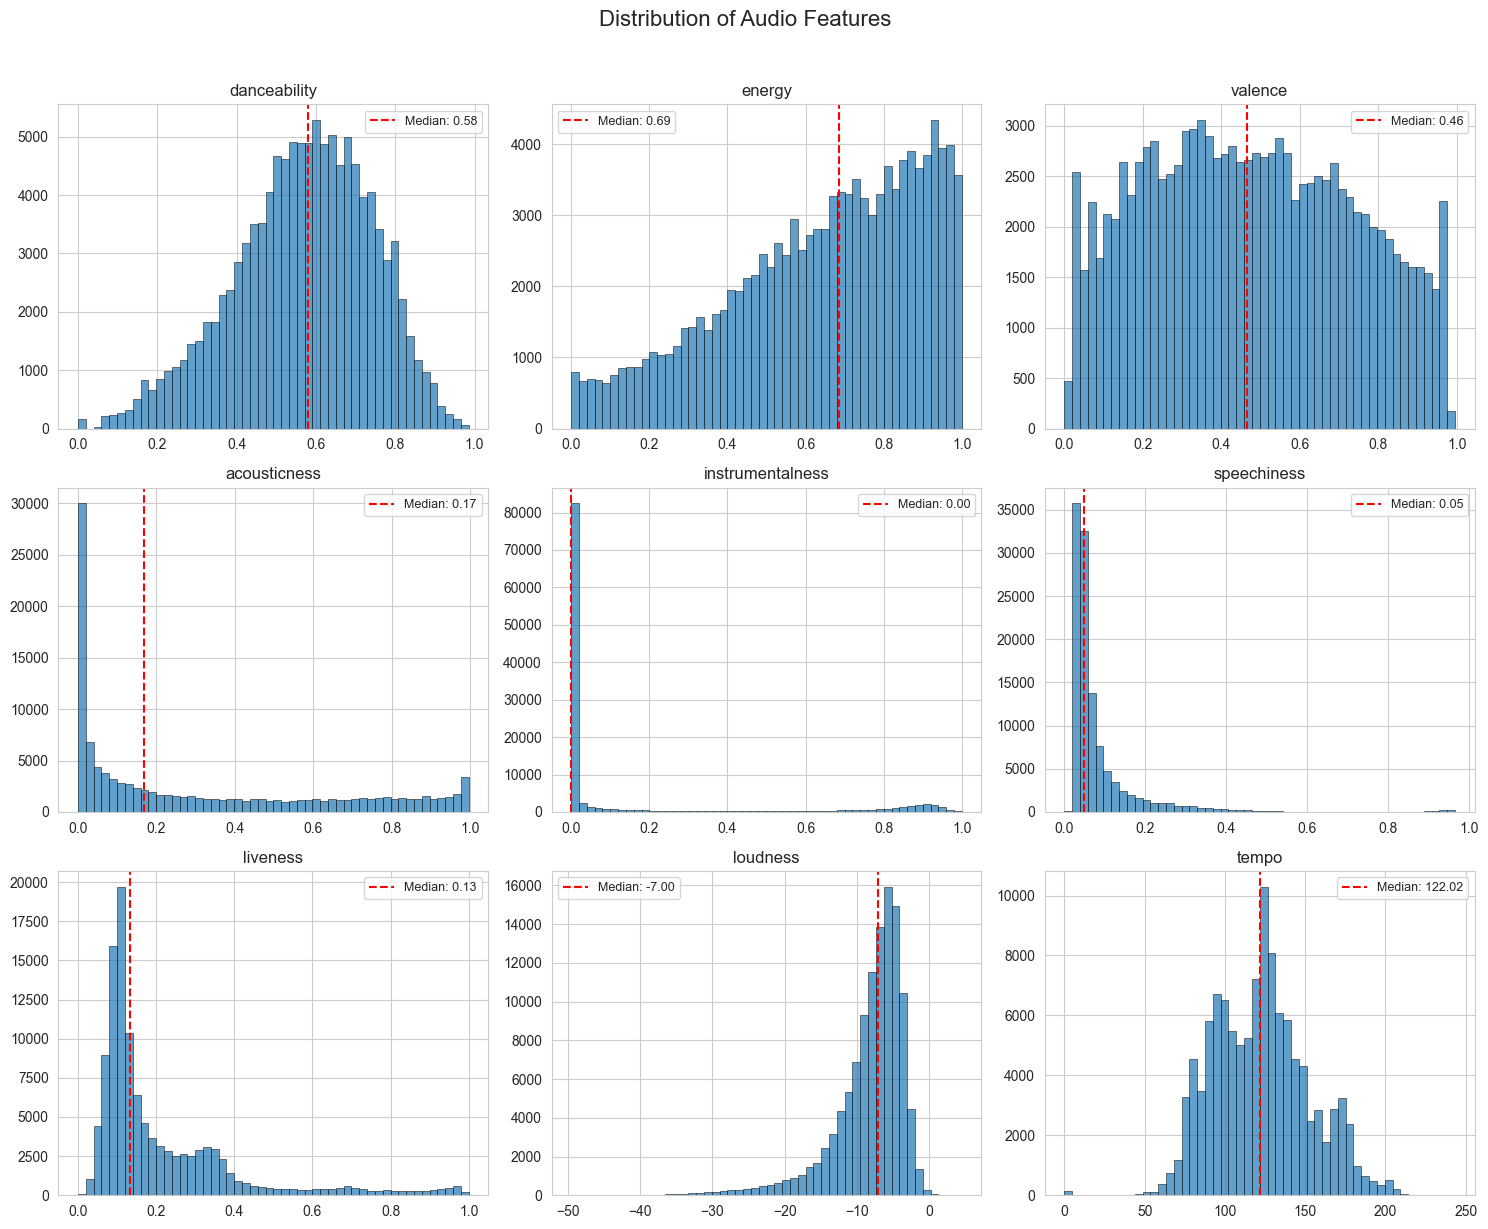

In [6]:
audioFeatures = ['danceability', 'energy', 'valence', 'acousticness', 
                  'instrumentalness', 'speechiness', 'liveness', 'loudness', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, feat in enumerate(audioFeatures):
    ax = axes[i // 3, i % 3]
    df[feat].dropna().hist(bins=50, ax=ax, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(feat)
    median_val = df[feat].median()
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Audio Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


danceability and energy look pretty normal. instrumentalness and speechiness are super skewed right — most songs have vocals. acousticness looks kind of bimodal which is interesting, songs are either acoustic or not.


### box plots to check for outliers


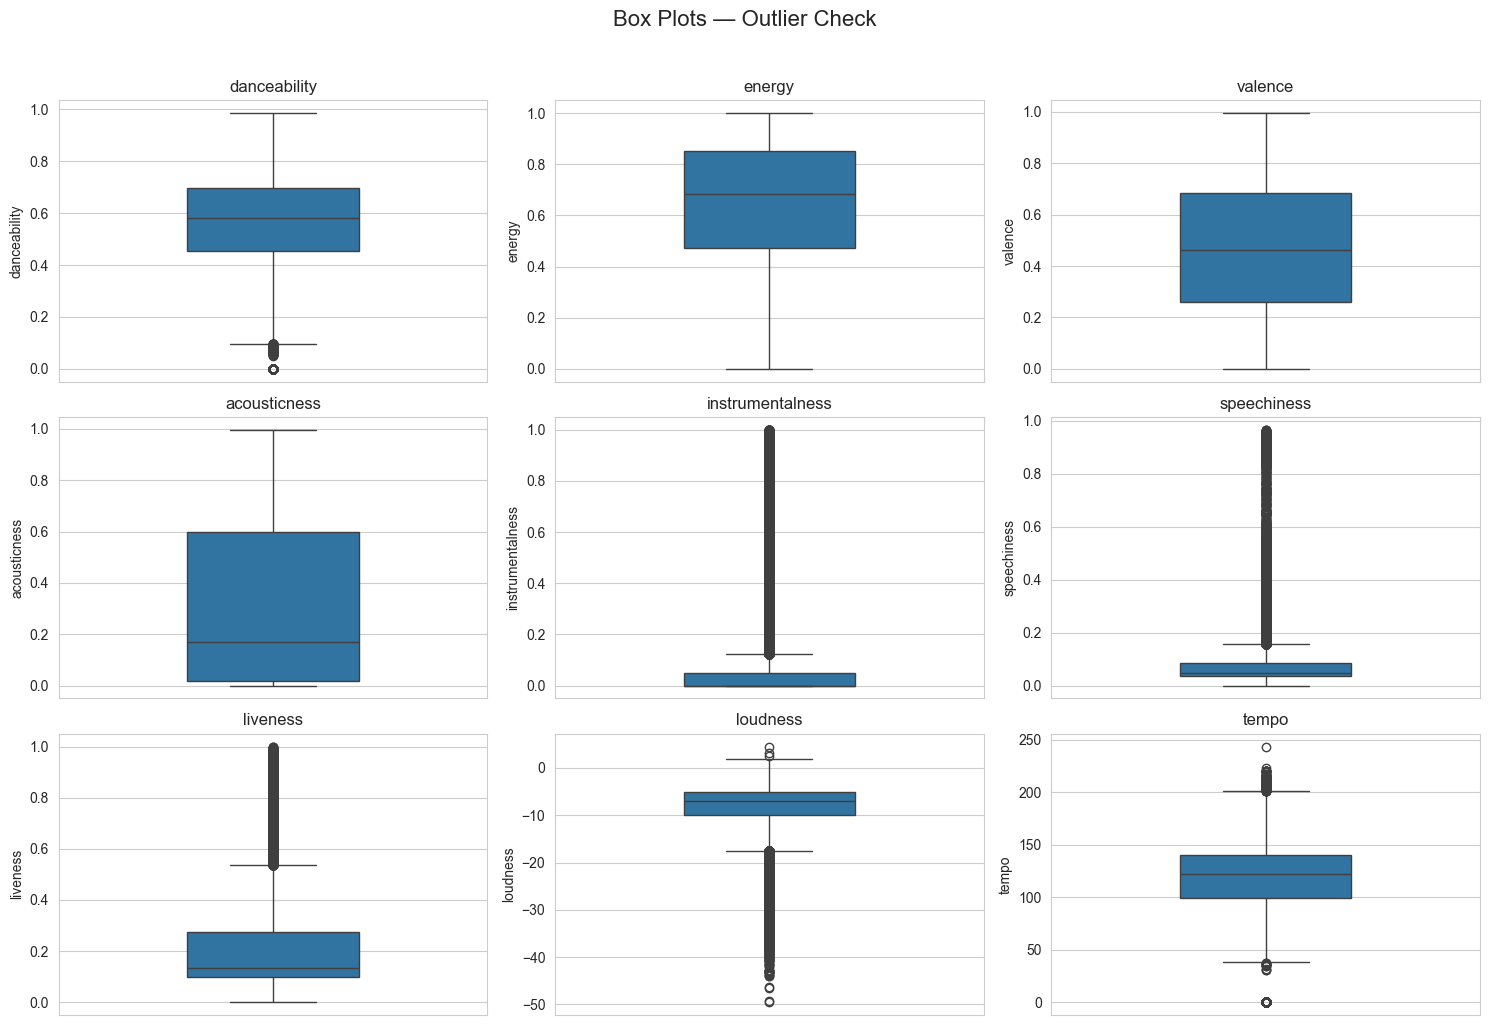

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for i, feat in enumerate(audioFeatures):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=df, y=feat, ax=ax, width=0.4)
    ax.set_title(feat)

plt.suptitle('Box Plots — Outlier Check', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/fig2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


speechiness and liveness have outliers but those are probably just spoken word tracks and live recordings. not actual errors so keeping them.


### correlation matrix


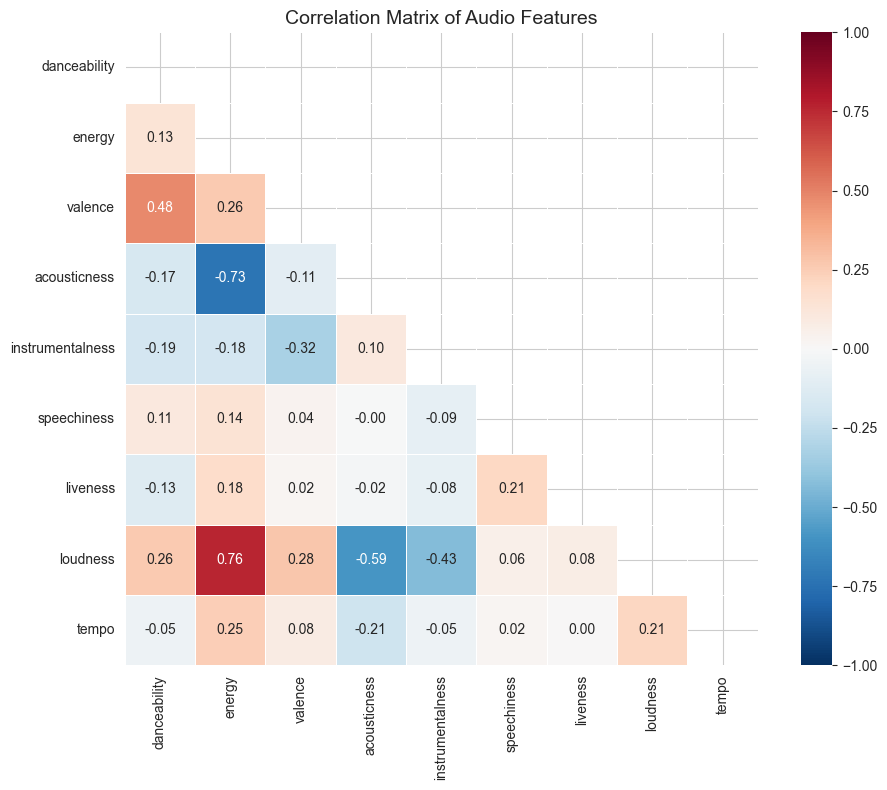

In [8]:
corr = df[audioFeatures].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix of Audio Features', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/fig3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


energy and loudness are strongly correlated (makes sense). energy and acousticness are negatively correlated. most other features are pretty independent which is good for clustering.


### scatter plots for interesting pairs


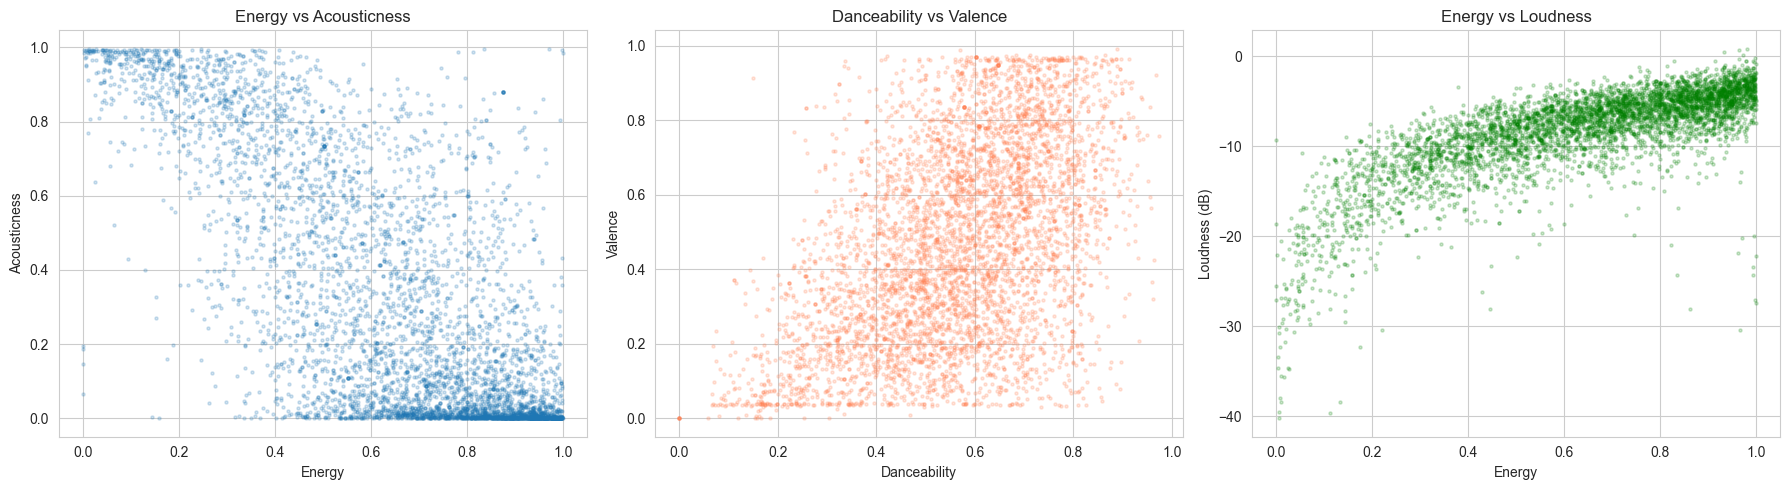

In [9]:
sample_df = df.sample(n=5000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(sample_df['energy'], sample_df['acousticness'], alpha=0.2, s=5)
axes[0].set_xlabel('Energy')
axes[0].set_ylabel('Acousticness')
axes[0].set_title('Energy vs Acousticness')

axes[1].scatter(sample_df['danceability'], sample_df['valence'], alpha=0.2, s=5, c='coral')
axes[1].set_xlabel('Danceability')
axes[1].set_ylabel('Valence')
axes[1].set_title('Danceability vs Valence')

axes[2].scatter(sample_df['energy'], sample_df['loudness'], alpha=0.2, s=5, c='green')
axes[2].set_xlabel('Energy')
axes[2].set_ylabel('Loudness (dB)')
axes[2].set_title('Energy vs Loudness')

plt.tight_layout()
plt.savefig('../outputs/figures/fig4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


energy vs acousticness has a clear inverse pattern. energy vs loudness is basically linear. danceability vs valence has a slight positive trend but lots of scatter.


### genre profiles


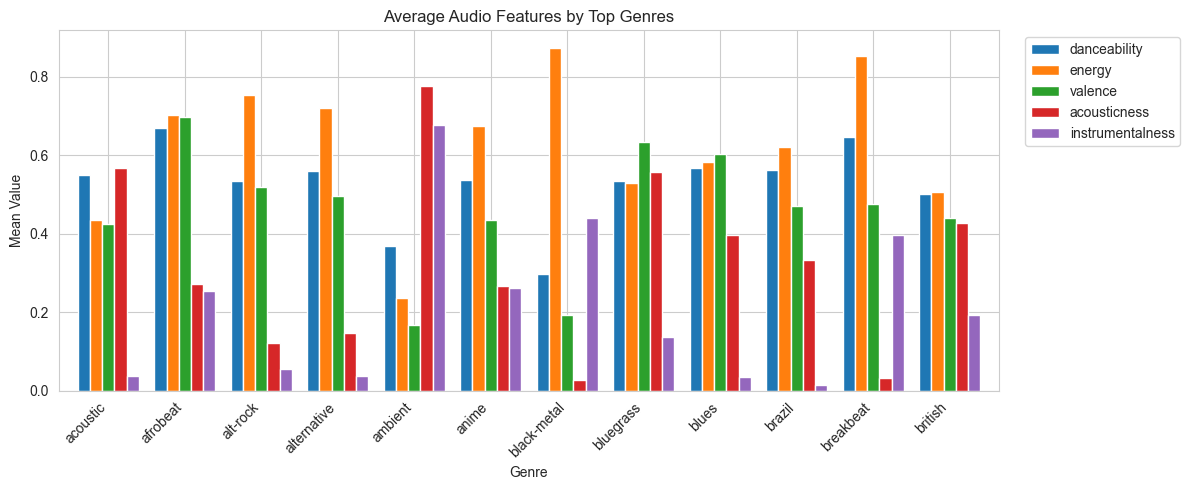

In [10]:
topGenres = df['track_genre'].value_counts().head(12).index.tolist()
df_top = df[df['track_genre'].isin(topGenres)]

# print(df['track_genre'].value_counts().head(20))

fig, ax = plt.subplots(figsize=(12, 5))
genreMeans = df_top.groupby('track_genre')[['danceability', 'energy', 'valence', 
                                               'acousticness', 'instrumentalness']].mean()
genreMeans.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average Audio Features by Top Genres')
ax.set_xlabel('Genre')
ax.set_ylabel('Mean Value')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/fig5_genre_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


genres do have different profiles but there's a lot of overlap between pop/dance/electronic. classical and metal are the most distinct. this makes me think clustering on audio features will find groups that don't match genre labels exactly.


### popularity by genre


C:\Users\Noah\AppData\Local\Temp\ipykernel_32144\4182923642.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


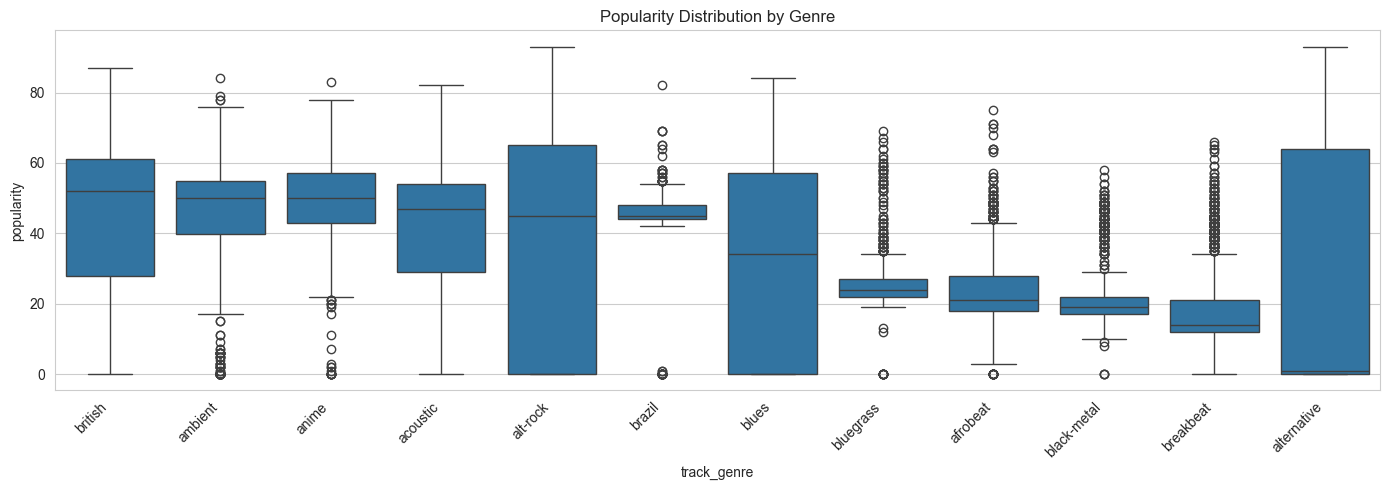

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
genreOrder = df_top.groupby('track_genre')['popularity'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top, x='track_genre', y='popularity', order=genreOrder, ax=ax)
ax.set_title('Popularity Distribution by Genre')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/fig6_popularity.png', dpi=150, bbox_inches='tight')
plt.show()


popularity is all over the place within each genre. not really driven by genre alone.


### track duration


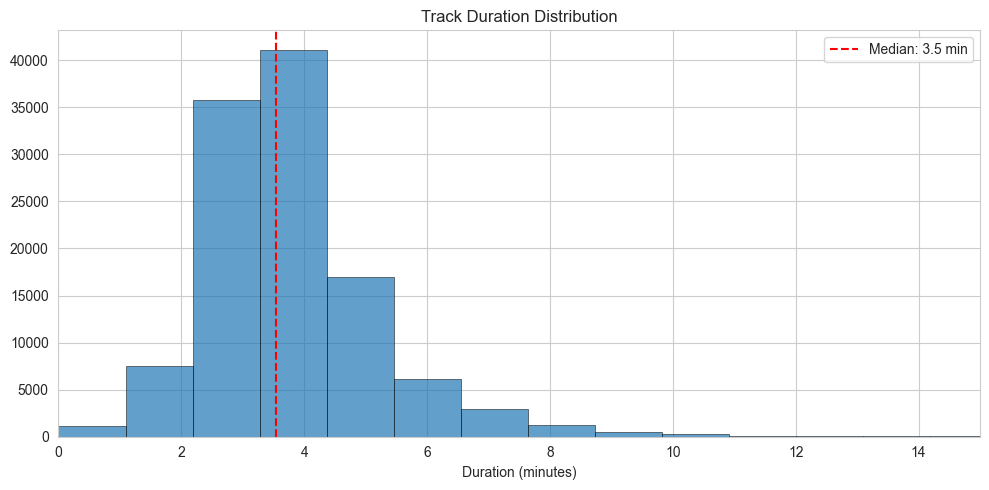

In [12]:
dur_minutes = df['duration_ms'] / 60000
# print(dur_minutes.describe())

fig, ax = plt.subplots(figsize=(10, 5))
dur_minutes.hist(bins=80, ax=ax, alpha=0.7, edgecolor='black', linewidth=0.5)
ax.axvline(dur_minutes.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {dur_minutes.median():.1f} min')
ax.set_title('Track Duration Distribution')
ax.set_xlabel('Duration (minutes)')
ax.set_xlim(0, 15)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/fig7_duration.png', dpi=150, bbox_inches='tight')
plt.show()


most songs are around 3-4 minutes. some really long ones but that's fine.


## 3. Preprocessing


### missing values


In [13]:
print(df.isnull().sum())
print()
print(f"rows with any null: {df.isnull().any(axis=1).sum()}")


track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

rows with any null: 1


In [14]:
rows_before = len(df)
df.dropna(subset=['artists', 'album_name', 'track_name'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"dropped {rows_before - len(df)} rows with missing metadata")
print(f"shape now: {df.shape}")


dropped 1 rows with missing metadata
shape now: (113999, 20)


only a rows had missing artist/album/track names. no missing audio features at all.


### duplicates


In [15]:
print(f"exact duplicate rows: {df.duplicated().sum()}")
print(f"duplicate track_ids: {df.duplicated(subset=['track_id']).sum()}")


exact duplicate rows: 450
duplicate track_ids: 24259


In [16]:
df = df.drop_duplicates(subset=['track_id'], keep='first').reset_index(drop=True)
print(f"shape after dedup: {df.shape}")


shape after dedup: (89740, 20)


In [17]:
# checking if any tracks show up under multiple genres
trackGenreCounts = df.groupby('track_id')['track_genre'].nunique()
print(f"tracks in multiple genres: {(trackGenreCounts > 1).sum()}")


tracks in multiple genres: 0


~24k duplicate track ids, probably tracks listed under multiple genres. removed them. after dedup no tracks appear in multiple genres anymore since we kept first occurrence.


### outlier check


In [18]:
for feat in audioFeatures:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[feat] < lower) | (df[feat] > upper)).sum()
    print(f"{feat}: {n_outliers} outliers ({n_outliers/len(df)*100:.2f}%)")


danceability: 474 outliers (0.53%)
energy: 0 outliers (0.00%)
valence: 0 outliers (0.00%)
acousticness: 0 outliers (0.00%)
instrumentalness: 19613 outliers (21.86%)
speechiness: 10644 outliers (11.86%)
liveness: 6981 outliers (7.78%)
loudness: 5026 outliers (5.60%)
tempo: 514 outliers (0.57%)


keeping all outliers since they're legit (live tracks, spoken word, etc).


### quick sanity check on value ranges


In [19]:
bounded = ['danceability', 'energy', 'valence', 'acousticness', 
           'instrumentalness', 'speechiness', 'liveness']
for feat in bounded:
    bad = ((df[feat] < 0) | (df[feat] > 1)).sum()
    if bad > 0:
        print(f"WARNING: {feat} has {bad} values outside [0,1]")
    # else:
    #     print(f"{feat} ok")

print(f"loudness range: {df['loudness'].min():.1f} to {df['loudness'].max():.1f}")
print(f"tempo range: {df['tempo'].min():.1f} to {df['tempo'].max():.1f}")
print(f"duration range: {df['duration_ms'].min()} to {df['duration_ms'].max()}")


loudness range: -49.5 to 4.5
tempo range: 0.0 to 243.4
duration range: 8586 to 5237295


everything looks clean. no weird values.


## 4. Transformation

standardizing features so clustering works properly


In [20]:
clustering_features = ['danceability', 'energy', 'valence', 'acousticness', 
                       'instrumentalness', 'speechiness', 'liveness', 'loudness', 'tempo']

X = df[clustering_features].copy()
print(f"shape: {X.shape}")
print(f"any nulls: {X.isnull().sum().sum()}")


shape: (89740, 9)
any nulls: 0


In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# print(pd.DataFrame(X_scaled, columns=clustering_features).describe())


z-score standardized everything. without this, loudness and tempo would dominate since they're on way bigger scales than the 0-1 features.


### PCA


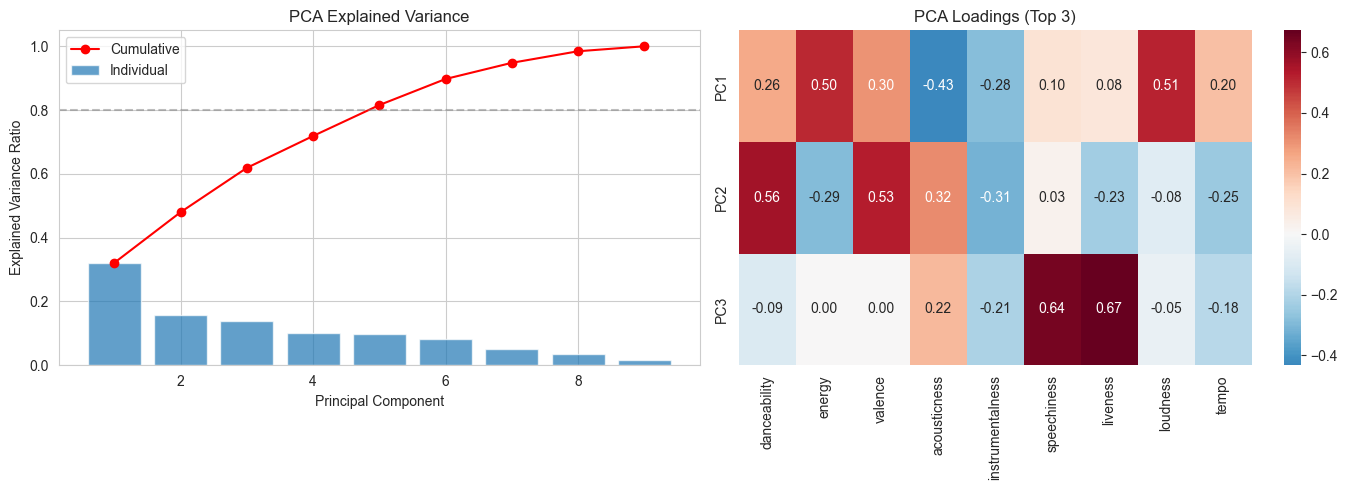

first 2 PCs: 47.99%
first 3 PCs: 61.88%


In [22]:
pca_full = PCA()
pca_full.fit(X_scaled)

cumVar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
            pca_full.explained_variance_ratio_, alpha=0.7, label='Individual')
axes[0].plot(range(1, len(cumVar) + 1), cumVar, 'ro-', label='Cumulative')
axes[0].axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Explained Variance')
axes[0].legend()

loadings = pd.DataFrame(pca_full.components_[:3], 
                        columns=clustering_features,
                        index=['PC1', 'PC2', 'PC3'])
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_title('PCA Loadings (Top 3)')

plt.tight_layout()
plt.savefig('../outputs/figures/fig8_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"first 2 PCs: {cumVar[1]:.2%}")
print(f"first 3 PCs: {cumVar[2]:.2%}")


PC1 is basically an acoustic vs produced axis (energy/loudness vs acousticness). PC2 picks up danceability and valence stuff. need quite a few components to get to 80% which means the data is genuinely multidimensional.


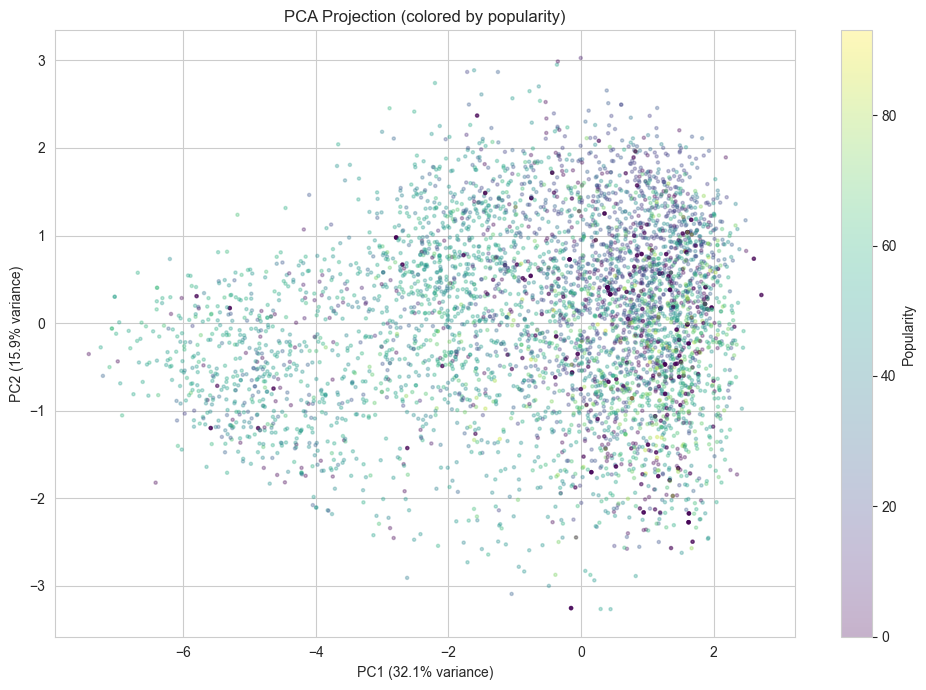

In [23]:
pca2d = PCA(n_components=2)
X_pca = pca2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:5000, 0], X_pca[:5000, 1], 
                     c=df['popularity'].values[:5000], cmap='viridis', 
                     alpha=0.3, s=5)
plt.colorbar(scatter, ax=ax, label='Popularity')
ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA Projection (colored by popularity)')
plt.tight_layout()
plt.savefig('../outputs/figures/fig9_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


you can kind of see structure here. popularity doesn't seem to cluster in any one area though.


## 5. Clustering — K-Means

### finding the right k


In [24]:
K_range = range(2, 11)
inertias = []
sil_scores = []

np.random.seed(42)
sampleIdx = np.random.choice(len(X_scaled), size=15000, replace=False)
X_sample = X_scaled[sampleIdx]

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels, sample_size=5000, random_state=42))
    print(f"k={k}: inertia={km.inertia_:.0f}, silhouette={sil_scores[-1]:.4f}")


k=2: inertia=105102, silhouette=0.2646
k=3: inertia=93244, silhouette=0.1632
k=4: inertia=83946, silhouette=0.1707
k=5: inertia=75817, silhouette=0.1784
k=6: inertia=68954, silhouette=0.1880
k=7: inertia=62874, silhouette=0.1956
k=8: inertia=59442, silhouette=0.1796
k=9: inertia=56247, silhouette=0.1824
k=10: inertia=53821, silhouette=0.1697


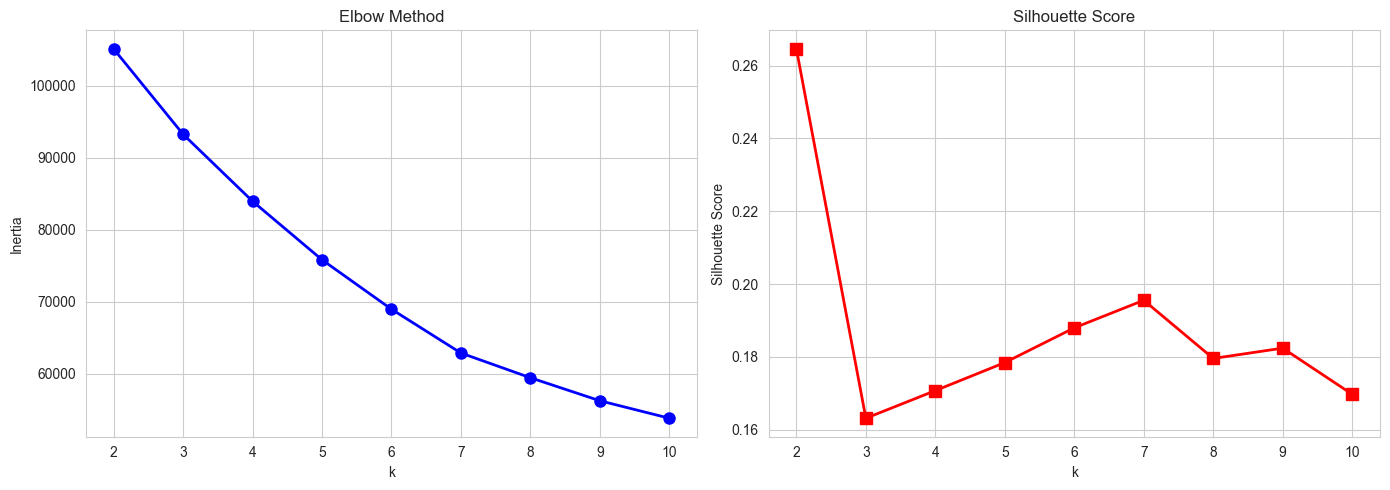

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('../outputs/figures/fig10_elbow.png', dpi=150, bbox_inches='tight')
plt.show()


elbow is around 4-5. silhouette is highest at k=2 but that's too few to be interesting. going with k=5.


### running k=5


In [26]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"silhouette: {silhouette_score(X_scaled, df['cluster'], sample_size=10000, random_state=42):.4f}")
print(f"davies-bouldin: {davies_bouldin_score(X_scaled, df['cluster']):.4f}")
print()
print(df['cluster'].value_counts().sort_index())


silhouette: 0.1774
davies-bouldin: 1.5165

cluster
0    26856
1    20830
2    33656
3     7296
4     1102
Name: count, dtype: int64


### clusters in PCA space


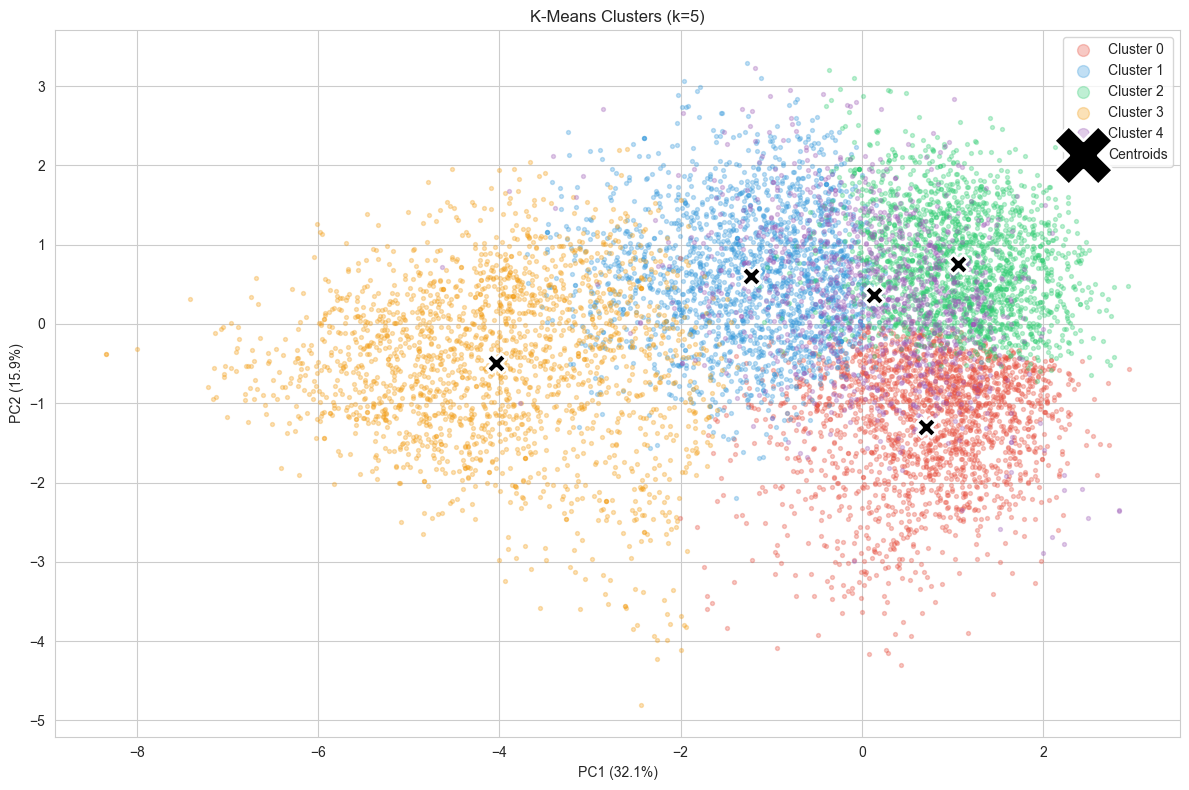

In [27]:
X_pca_all = pca2d.transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
clusterColors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for i in range(5):
    mask = df['cluster'] == i
    idx = np.where(mask)[0]
    if len(idx) > 2000:
        idx = np.random.choice(idx, 2000, replace=False)
    ax.scatter(X_pca_all[idx, 0], X_pca_all[idx, 1], 
               c=clusterColors[i], alpha=0.3, s=8, label=f'Cluster {i}')

centroids_pca = pca2d.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=200, 
           edgecolors='white', linewidths=2, zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%})')
ax.set_title('K-Means Clusters (k=5)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../outputs/figures/fig11_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()


clusters separate decently in PCA space. some overlap but that's expected since we're projecting 9 dimensions down to 2.


### cluster profiles


In [28]:
print(df.groupby('cluster')[clustering_features].mean().round(3).to_string())


         danceability  energy  valence  acousticness  instrumentalness  speechiness  liveness  loudness    tempo
cluster                                                                                                         
0               0.476   0.821    0.322         0.068             0.238        0.084     0.264    -5.988  136.196
1               0.535   0.391    0.402         0.666             0.062        0.056     0.186   -10.485  113.797
2               0.693   0.730    0.693         0.207             0.065        0.093     0.194    -6.541  120.664
3               0.353   0.198    0.179         0.821             0.781        0.052     0.172   -20.716  103.092
4               0.573   0.674    0.448         0.730             0.008        0.826     0.666   -11.085  101.823


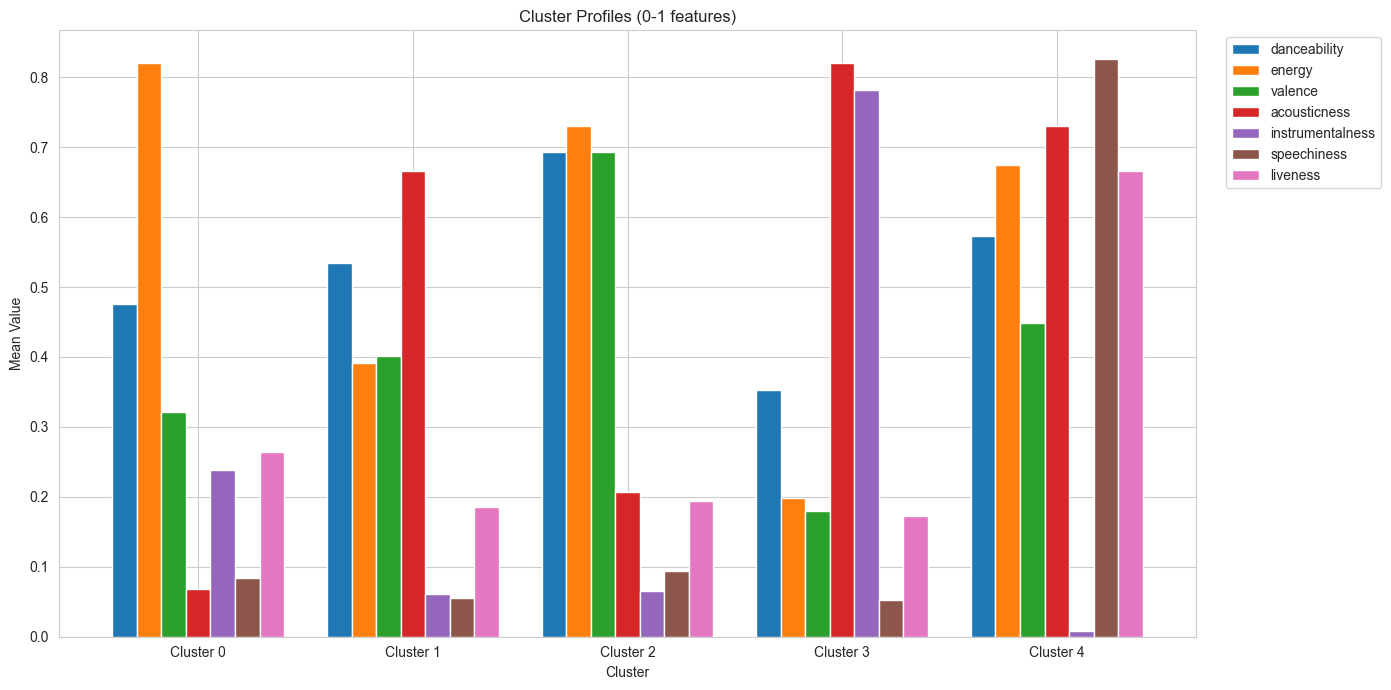

In [29]:
fig, ax = plt.subplots(figsize=(14, 7))
features_01 = ['danceability', 'energy', 'valence', 'acousticness', 
               'instrumentalness', 'speechiness', 'liveness']

df.groupby('cluster')[features_01].mean().plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Cluster Profiles (0-1 features)')
ax.set_xlabel('Cluster')
ax.set_ylabel('Mean Value')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels([f'Cluster {i}' for i in range(5)], rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/fig12_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


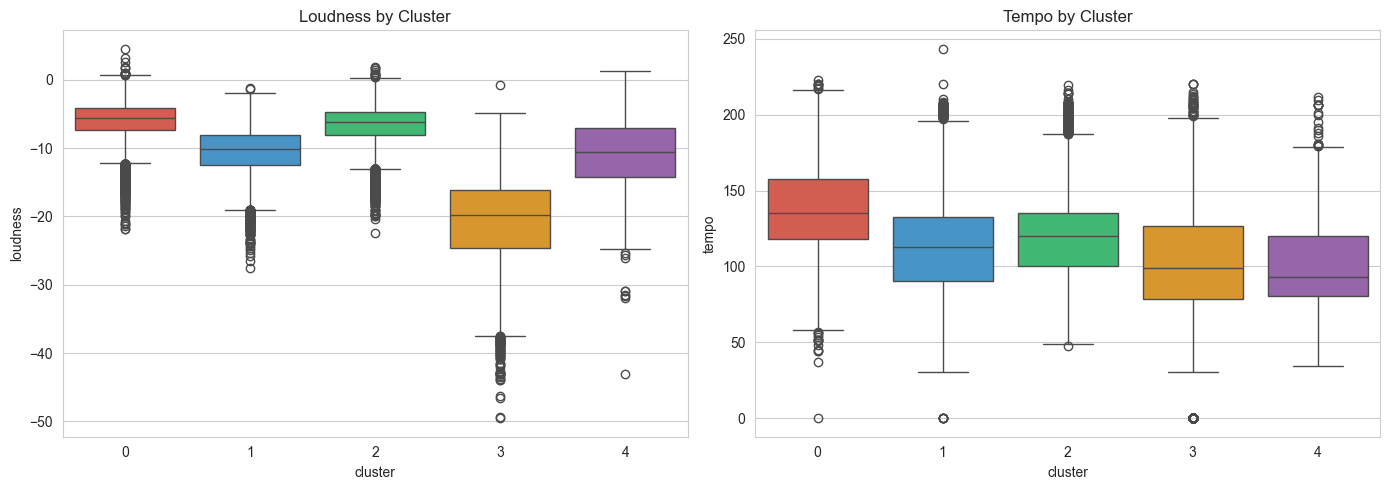

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='cluster', y='loudness', hue='cluster',
            palette=clusterColors, legend=False, ax=axes[0])
axes[0].set_title('Loudness by Cluster')

sns.boxplot(data=df, x='cluster', y='tempo', hue='cluster',
            palette=clusterColors, legend=False, ax=axes[1])
axes[1].set_title('Tempo by Cluster')

plt.tight_layout()
plt.savefig('../outputs/figures/fig13_loudness_tempo.png', dpi=150, bbox_inches='tight')
plt.show()


### what's in each cluster?


In [31]:
for c in range(5):
    profile = df[df['cluster'] == c][clustering_features].mean()
    n = len(df[df['cluster'] == c])
    top_g = df[df['cluster'] == c]['track_genre'].value_counts().head(5)
    
    print(f"\n--- Cluster {c} (n={n:,}) ---")
    print(f"  dance={profile['danceability']:.3f}  energy={profile['energy']:.3f}  valence={profile['valence']:.3f}")
    print(f"  acoustic={profile['acousticness']:.3f}  instrumental={profile['instrumentalness']:.3f}")
    print(f"  speech={profile['speechiness']:.3f}  live={profile['liveness']:.3f}")
    print(f"  loudness={profile['loudness']:.1f}dB  tempo={profile['tempo']:.0f}BPM")
    print(f"  top genres: {', '.join(top_g.index.tolist())}")



--- Cluster 0 (n=26,856) ---
  dance=0.476  energy=0.821  valence=0.322
  acoustic=0.068  instrumental=0.238
  speech=0.084  live=0.264
  loudness=-6.0dB  tempo=136BPM
  top genres: grindcore, black-metal, death-metal, heavy-metal, happy

--- Cluster 1 (n=20,830) ---
  dance=0.535  energy=0.391  valence=0.402
  acoustic=0.666  instrumental=0.062
  speech=0.056  live=0.186
  loudness=-10.5dB  tempo=114BPM
  top genres: tango, honky-tonk, cantopop, romance, acoustic

--- Cluster 2 (n=33,656) ---
  dance=0.693  energy=0.730  valence=0.693
  acoustic=0.207  instrumental=0.065
  speech=0.093  live=0.194
  loudness=-6.5dB  tempo=121BPM
  top genres: salsa, dancehall, forro, kids, chicago-house

--- Cluster 3 (n=7,296) ---
  dance=0.353  energy=0.198  valence=0.179
  acoustic=0.821  instrumental=0.781
  speech=0.052  live=0.172
  loudness=-20.7dB  tempo=103BPM
  top genres: sleep, new-age, ambient, classical, iranian

--- Cluster 4 (n=1,102) ---
  dance=0.573  energy=0.674  valence=0.448
  a

### cluster names

based on the profiles above:
- **Cluster 0:** high energy, low valence, loud -- dark/intense stuff (metal, grindcore, hard-rock)
- **Cluster 1:** moderate everything, leaning acoustic -- softer mid-range (tango, honky-tonk, romance)
- **Cluster 2:** danceable, upbeat, moderate-high energy -- mainstream/upbeat (salsa, dancehall, pop)
- **Cluster 3:** very low energy, high acousticness/instrumentalness, quiet -- ambient/classical
- **Cluster 4:** extremely high speechiness -- basically spoken word (73% comedy)


each cluster has a distinct profile. you can see clear differences — one is very acoustic/instrumental, another is loud and energetic, etc. the top genres in each cluster make sense with the audio profiles.


### genre purity — do clusters match genre labels?


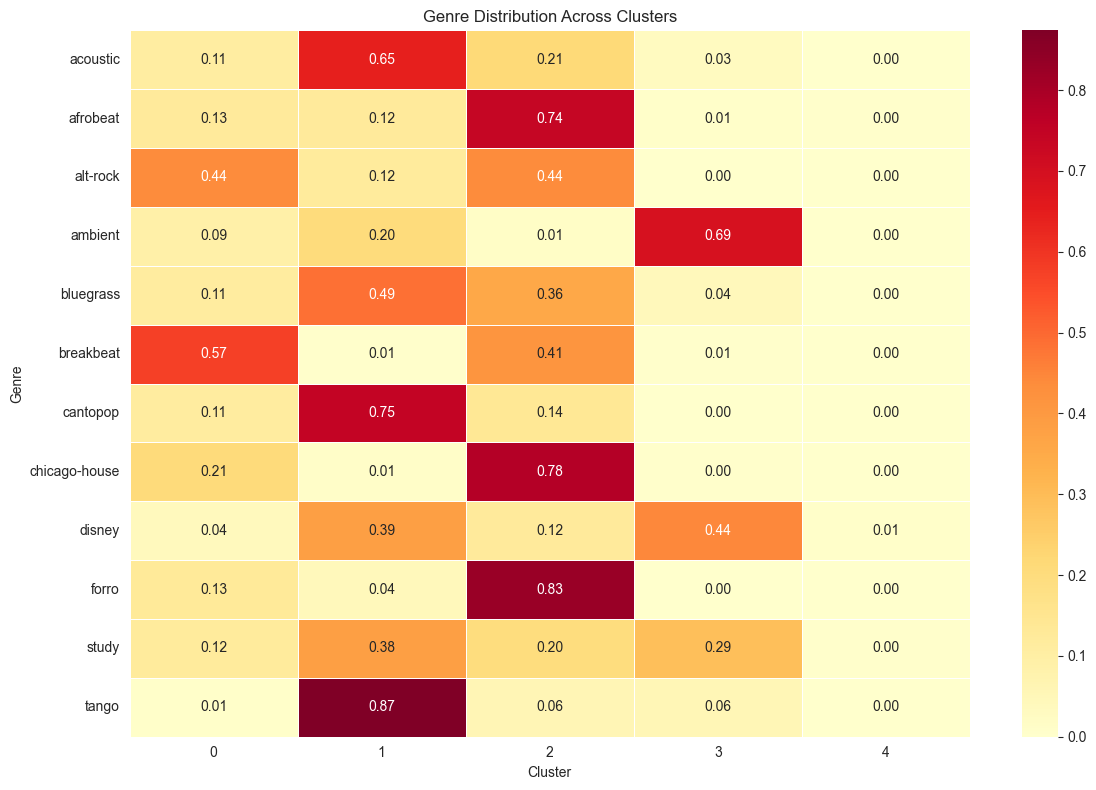

In [32]:
top12 = df['track_genre'].value_counts().head(12).index
df_top12 = df[df['track_genre'].isin(top12)]

ct = pd.crosstab(df_top12['track_genre'], df_top12['cluster'], normalize='index').round(3)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Genre Distribution Across Clusters')
ax.set_xlabel('Cluster')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.savefig('../outputs/figures/fig14_genre_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


genres don't map cleanly to clusters. most genres are spread across multiple clusters. this confirms what we expected — audio-based clustering reveals patterns that cross genre boundaries. pop and electronic end up in similar clusters because they sound similar even though they're labeled differently.


## 6. Findings

**primary question — what clusters emerge?**
5 distinct sonic archetypes. each has a clear audio profile and the top genres in each cluster make sense. see the profiling above for details.

**supporting question — latent dimensions?**
PCA shows the main axis is acoustic vs produced (energy/loudness vs acousticness). second axis is more about danceability/valence.

**surprises:** pop and electronic overlap a lot. the acoustic cluster is really cohesive.

**limitations:** k-means assumes spherical clusters, k=5 is somewhat arbitrary, audio features miss lyrical/cultural aspects of genre.

**for M3:** try DBSCAN, train decision trees on cluster labels for interpretable rules, group the 114 genres into broader families.


In [33]:
print(f"done. {len(df):,} tracks, {df['track_genre'].nunique()} genres, 5 clusters")


done. 89,740 tracks, 113 genres, 5 clusters


---
# Milestone 3: Complete Implementation

Adding DBSCAN, decision trees, and anomaly detection on top of the M2 analysis above.


In [34]:
# additional imports for M3
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.neighbors import LocalOutlierFactor


## 3. DBSCAN Clustering

DBSCAN doesn't need you to pick k ahead of time, and it can find noise points (outliers). Running on a 20k sample because DBSCAN with ~90k rows in 9 dimensions is really slow.

### parameter search

trying a few eps / min_samples combos to see what works.

In [35]:
np.random.seed(42)
dbscan_idx = np.random.choice(len(X_scaled), size=20000, replace=False)
X_dbscan = X_scaled[dbscan_idx]

results = []
for eps_val in [1.5, 2.0, 2.5, 3.0]:
    for ms in [10, 15, 20]:
        db = DBSCAN(eps=eps_val, min_samples=ms)
        labels = db.fit_predict(X_dbscan)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        results.append({'eps': eps_val, 'min_samples': ms, 'clusters': n_clusters, 
                       'noise': n_noise, 'noise_pct': round(n_noise/len(X_dbscan)*100, 1)})
        print(f"eps={eps_val}, min_samples={ms}: {n_clusters} clusters, {n_noise} noise ({n_noise/len(X_dbscan)*100:.1f}%)")

eps=1.5, min_samples=10: 3 clusters, 469 noise (2.3%)
eps=1.5, min_samples=15: 2 clusters, 578 noise (2.9%)
eps=1.5, min_samples=20: 2 clusters, 647 noise (3.2%)
eps=2.0, min_samples=10: 2 clusters, 127 noise (0.6%)
eps=2.0, min_samples=15: 3 clusters, 144 noise (0.7%)
eps=2.0, min_samples=20: 2 clusters, 181 noise (0.9%)
eps=2.5, min_samples=10: 1 clusters, 37 noise (0.2%)
eps=2.5, min_samples=15: 1 clusters, 42 noise (0.2%)
eps=2.5, min_samples=20: 1 clusters, 46 noise (0.2%)
eps=3.0, min_samples=10: 1 clusters, 5 noise (0.0%)
eps=3.0, min_samples=15: 1 clusters, 8 noise (0.0%)
eps=3.0, min_samples=20: 1 clusters, 20 noise (0.1%)


eps=2.5+ collapses everything into 1 cluster. eps=1.5 gives 2 clusters with ~3% noise. eps=2.0 gives 3 clusters with less noise. going with eps=2.0, min_samples=15 as a middle ground -- enough structure but not too noisy.

In [36]:
dbscan = DBSCAN(eps=2.0, min_samples=15)
db_labels = dbscan.fit_predict(X_dbscan)
df_dbscan = df.iloc[dbscan_idx].copy()
df_dbscan['dbscan_label'] = db_labels

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f"DBSCAN found {n_db_clusters} clusters and {n_noise} noise points ({n_noise/len(db_labels)*100:.1f}%)")
print(pd.Series(db_labels).value_counts().sort_index())

DBSCAN found 3 clusters and 144 noise points (0.7%)
-1      144
 0    19677
 1      154
 2       25
Name: count, dtype: int64


3 clusters but very uneven -- one massive cluster (19k+), one small one (~150), and a tiny one (~25). plus ~144 noise points. DBSCAN is seeing the data as mostly one big dense blob with a couple small offshoots.

### DBSCAN vs K-Means

In [37]:
km_labels_sample = df['cluster'].values[dbscan_idx]

ct = pd.crosstab(pd.Series(km_labels_sample, name='KMeans'), 
                 pd.Series(db_labels, name='DBSCAN'))
print(ct)

DBSCAN  -1     0    1   2
KMeans                   
0       10  5909    0   5
1       10  4642    0   0
2        1  7590    0   0
3       86  1494    0  20
4       37    42  154   0


K-Means cluster 4 (the hip-hop/speech cluster) maps almost perfectly to DBSCAN cluster 1. the rest all get lumped into DBSCAN cluster 0. this makes sense -- most audio features form one big continuous distribution, and only the high-speechiness tracks are truly separated by density. K-Means forces 5 groups even where there's no real density gap.

### silhouette comparison

In [38]:
km_sil = silhouette_score(X_scaled, df['cluster'], sample_size=10000, random_state=42)
print(f"K-Means (k=5): {km_sil:.4f}")

non_noise = db_labels != -1
if len(set(db_labels[non_noise])) > 1:
    db_sil = silhouette_score(X_dbscan[non_noise], db_labels[non_noise], 
                               sample_size=min(10000, non_noise.sum()), random_state=42)
    print(f"DBSCAN (eps=2.0, excl noise): {db_sil:.4f}")
    print(f"  ({non_noise.sum()} of {len(db_labels)} points, {len(set(db_labels[non_noise]))} clusters)")

K-Means (k=5): 0.1774
DBSCAN (eps=2.0, excl noise): 0.4145
  (19856 of 20000 points, 3 clusters)


DBSCAN's silhouette (0.41) is way higher than K-Means (0.18), but this is misleading. DBSCAN puts 98.5% of points in one cluster and only separates the most obvious outliers, so of course those well-separated pockets have high silhouette. K-Means is doing the harder job of splitting a continuous blob into 5 groups, which naturally produces more boundary overlap. higher silhouette doesn't mean DBSCAN is "better" here -- they're answering different questions.

### visualizing DBSCAN in PCA space

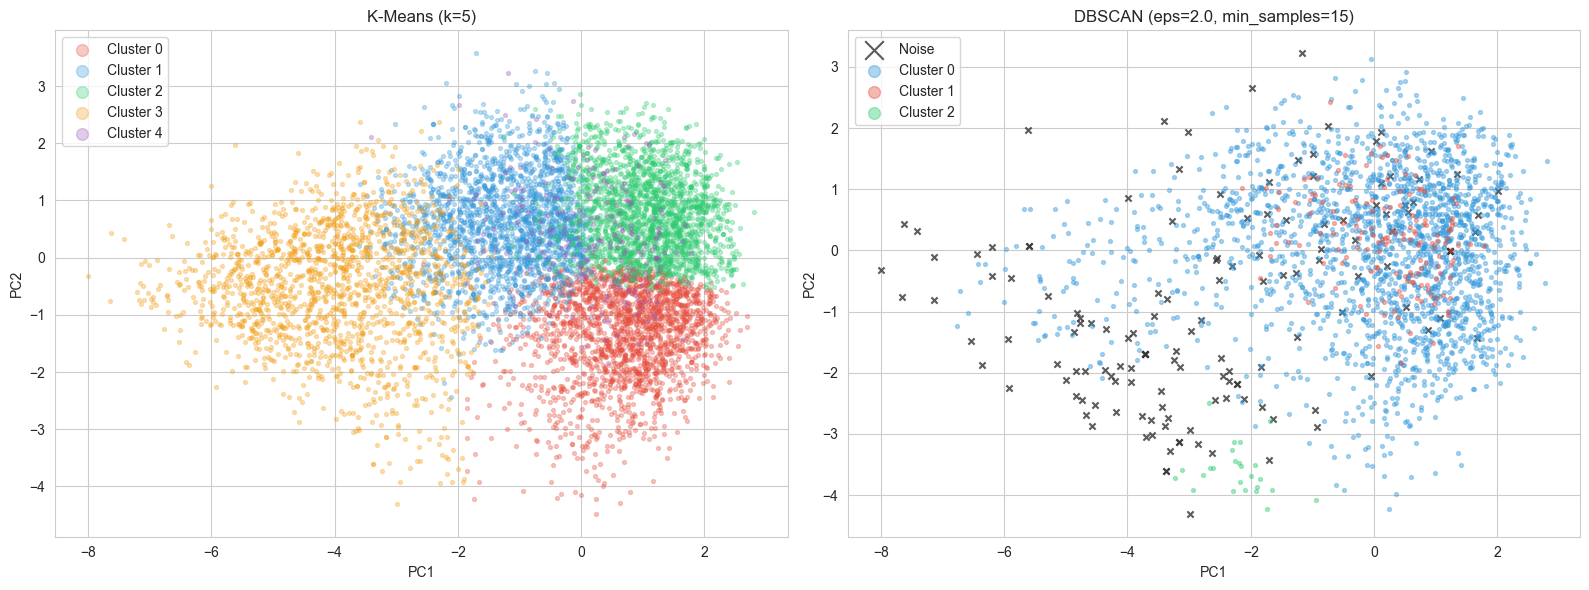

In [39]:
X_pca_dbscan = X_pca_all[dbscan_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# left: K-Means on same sample
for i in range(5):
    mask = km_labels_sample == i
    idx = np.where(mask)[0]
    if len(idx) > 2000:
        idx = np.random.choice(idx, 2000, replace=False)
    axes[0].scatter(X_pca_dbscan[idx, 0], X_pca_dbscan[idx, 1], 
                   c=clusterColors[i], alpha=0.3, s=8, label=f'Cluster {i}')
axes[0].set_title('K-Means (k=5)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3)

# right: DBSCAN
dbColors = {-1: '#333333', 0: '#3498db', 1: '#e74c3c', 2: '#2ecc71'}
dbLabels = {-1: 'Noise', 0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}
for lab in sorted(set(db_labels)):
    mask = db_labels == lab
    idx = np.where(mask)[0]
    if len(idx) > 2000:
        idx = np.random.choice(idx, 2000, replace=False)
    axes[1].scatter(X_pca_dbscan[idx, 0], X_pca_dbscan[idx, 1], 
                   c=dbColors.get(lab, '#999999'), alpha=0.4 if lab != -1 else 0.8, 
                   s=8 if lab != -1 else 20, label=dbLabels.get(lab, f'{lab}'),
                   marker='o' if lab != -1 else 'x')
axes[1].set_title('DBSCAN (eps=2.0, min_samples=15)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig('../outputs/figures/fig15_dbscan_vs_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

the noise points (black X's) sit on the edges of the distribution. DBSCAN's main cluster basically covers everything K-Means splits into 4 groups.

### what are the noise points?

In [40]:
noise_df = df_dbscan[df_dbscan['dbscan_label'] == -1]
print(f"{len(noise_df)} noise points")
print(f"\ntop genres in noise:")
print(noise_df['track_genre'].value_counts().head(10))

144 noise points

top genres in noise:
track_genre
sleep          65
comedy         10
iranian        10
study           7
world-music     5
jazz            5
show-tunes      4
funk            3
classical       3
children        3
Name: count, dtype: int64


In [41]:
print("\nsome noise tracks:")
for _, row in noise_df.sample(8, random_state=42).iterrows():
    print(f"  {row['track_name']} by {row['artists']} ({row['track_genre']})")
    print(f"    dance={row['danceability']:.2f} energy={row['energy']:.2f} acoustic={row['acousticness']:.2f} speech={row['speechiness']:.2f} inst={row['instrumentalness']:.2f} loud={row['loudness']:.1f}dB")


some noise tracks:
  White Noise (Loopable, No Fade) by Rain Sounds;Sleep Sounds of Nature (sleep)
    dance=0.00 energy=0.00 acoustic=0.36 speech=0.00 inst=0.90 loud=-29.6dB
  Pink Noise For Sleep 1 by Granular (sleep)
    dance=0.00 energy=0.01 acoustic=0.93 speech=0.00 inst=0.48 loud=-22.0dB
  Waves: White Noise Sleep by Ocean Waves For Sleep (sleep)
    dance=0.06 energy=0.29 acoustic=0.00 speech=0.26 inst=0.00 loud=-17.2dB
  What's the Time, Mr Wolf? by The Wiggles (children)
    dance=0.67 energy=0.40 acoustic=0.22 speech=0.81 inst=0.00 loud=-11.0dB
  Soothing Massage Rain by Nature Sounds (sleep)
    dance=0.08 energy=0.00 acoustic=0.00 speech=0.27 inst=0.57 loud=-23.3dB
  Salmon Benedict by Timothy Infinite (study)
    dance=0.72 energy=0.43 acoustic=0.93 speech=0.37 inst=0.80 loud=-11.1dB
  Down Down Baby by The Laurie Berkner Band (children)
    dance=0.71 energy=0.50 acoustic=0.83 speech=0.88 inst=0.00 loud=-11.4dB
  N Word by Chris Robinson (comedy)
    dance=0.60 energy=0

sleep, comedy, and iranian music dominate the noise points. these are genres with unusual audio profiles -- sleep tracks are extremely quiet and instrumental, comedy is basically spoken word, and iranian music has different tonal structures. makes sense that they'd be density outliers.

### what's in DBSCAN clusters 1 and 2?

they overlap with cluster 0 in PCA space, so let's see if they're actually different in the full 9D feature space.

In [42]:
for lab in sorted(df_dbscan['dbscan_label'].unique()):
    subset = df_dbscan[df_dbscan['dbscan_label'] == lab]
    name = f"Cluster {lab}" if lab != -1 else "Noise"
    print(f"\n--- {name} (n={len(subset)}) ---")
    for feat in clustering_features:
        print(f"  {feat}: {subset[feat].mean():.3f}")
    print(f"  top genres: {', '.join(subset['track_genre'].value_counts().head(4).index.tolist())}")


--- Noise (n=144) ---
  danceability: 0.299
  energy: 0.407
  valence: 0.246
  acousticness: 0.566
  instrumentalness: 0.481
  speechiness: 0.266
  liveness: 0.518
  loudness: -19.044
  tempo: 81.943
  top genres: sleep, comedy, iranian, study

--- Cluster 0 (n=19677) ---
  danceability: 0.565
  energy: 0.634
  valence: 0.474
  acousticness: 0.323
  instrumentalness: 0.170
  speechiness: 0.079
  liveness: 0.208
  loudness: -8.371
  tempo: 122.540
  top genres: forro, heavy-metal, club, bluegrass

--- Cluster 1 (n=154) ---
  danceability: 0.564
  energy: 0.732
  valence: 0.410
  acousticness: 0.805
  instrumentalness: 0.000
  speechiness: 0.902
  liveness: 0.777
  loudness: -10.932
  tempo: 95.654
  top genres: comedy, afrobeat, classical, children

--- Cluster 2 (n=25) ---
  danceability: 0.183
  energy: 0.978
  valence: 0.005
  acousticness: 0.360
  instrumentalness: 0.918
  speechiness: 0.056
  liveness: 0.882
  loudness: -20.696
  tempo: 94.813
  top genres: sleep, world-music


cluster 1 (154 tracks) has extremely high speechiness (0.90) and liveness (0.78) with zero instrumentalness -- these are live spoken-word performances, mostly comedy. cluster 2 (25 tracks) is the opposite extreme: near-max energy (0.98), near-zero valence (0.005), high instrumentalness (0.92), and high liveness (0.88) but very quiet (-20.7 dB). these are intense, dark, instrumental live recordings -- a really unusual combination.

they look overlapped in PCA space because PCA only captures ~48% of the variance. the features that separate them (speechiness, liveness, instrumentalness) load more on PC3+ which we're not showing. in 9D they're genuinely in different neighborhoods.

## 4. Decision Tree on Cluster Labels

Using the K-Means cluster assignments as the target variable. The goal isn't prediction accuracy -- it's to get interpretable rules for what defines each cluster.

In [43]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_scaled, df['cluster'])

print(f"training accuracy: {dt.score(X_scaled, df['cluster']):.4f}")
print("\n(this is high but we're not trying to generalize -- we want the rules)")

training accuracy: 0.8470

(this is high but we're not trying to generalize -- we want the rules)


### feature importances

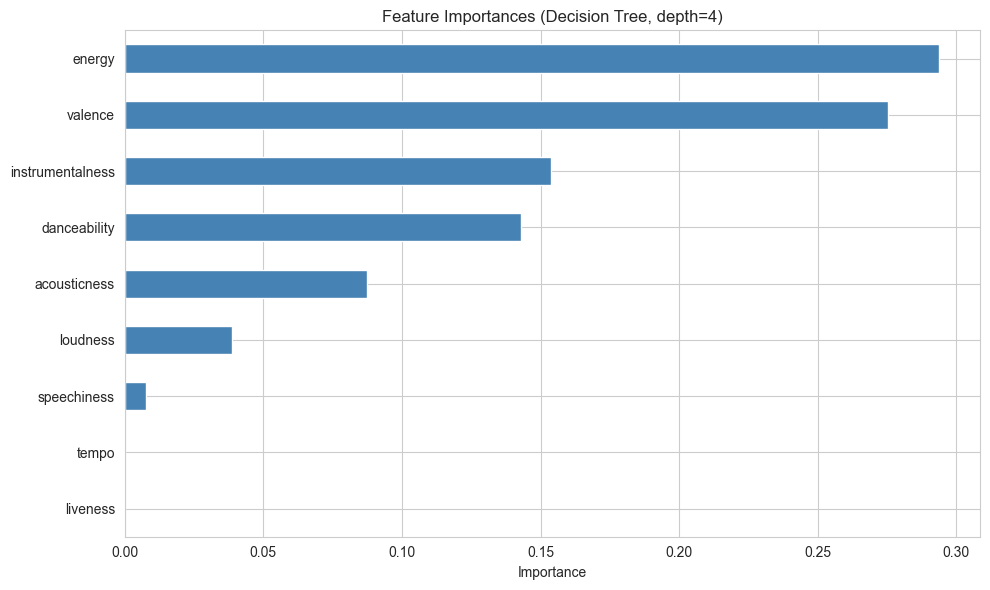

top features:
  energy: 0.294
  valence: 0.275
  instrumentalness: 0.154
  danceability: 0.143
  acousticness: 0.087
  loudness: 0.039


In [44]:
importances = pd.Series(dt.feature_importances_, index=clustering_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importances (Decision Tree, depth=4)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../outputs/figures/fig16_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print("top features:")
for feat, imp in importances.sort_values(ascending=False).items():
    if imp > 0.01:
        print(f"  {feat}: {imp:.3f}")

energy and valence are the most important splits, followed by instrumentalness and danceability. tempo and liveness basically don't matter for distinguishing clusters. this lines up with PCA where PC1 was mostly energy/acousticness and PC2 was valence/danceability.

### tree rules

In [45]:
print(export_text(dt, feature_names=clustering_features, max_depth=3))

|--- energy <= -0.32
|   |--- instrumentalness <= 1.09
|   |   |--- acousticness <= 0.02
|   |   |   |--- danceability <= 0.31
|   |   |   |   |--- class: 1
|   |   |   |--- danceability >  0.31
|   |   |   |   |--- class: 2
|   |   |--- acousticness >  0.02
|   |   |   |--- loudness <= -2.05
|   |   |   |   |--- class: 3
|   |   |   |--- loudness >  -2.05
|   |   |   |   |--- class: 1
|   |--- instrumentalness >  1.09
|   |   |--- loudness <= -0.89
|   |   |   |--- danceability <= 0.87
|   |   |   |   |--- class: 3
|   |   |   |--- danceability >  0.87
|   |   |   |   |--- class: 3
|   |   |--- loudness >  -0.89
|   |   |   |--- acousticness <= -0.33
|   |   |   |   |--- class: 0
|   |   |   |--- acousticness >  -0.33
|   |   |   |   |--- class: 1
|--- energy >  -0.32
|   |--- valence <= 0.14
|   |   |--- danceability <= 0.36
|   |   |   |--- acousticness <= 0.18
|   |   |   |   |--- class: 0
|   |   |   |--- acousticness >  0.18
|   |   |   |   |--- class: 1
|   |   |--- danceability

reading the rules (these are in standardized units):
- first split is energy: low energy songs go one way, high energy go another
- for low energy: if instrumentalness is high, it's cluster 3 (the quiet/instrumental group). otherwise acousticness separates cluster 1 from cluster 2
- for high energy: valence matters -- low valence + low danceability = cluster 0 (dark/intense). high valence + high danceability = cluster 2 (upbeat/mainstream). extreme speechiness = cluster 4 (hip-hop/rap)

these rules match the cluster profiles from M2 pretty well.

### tree on raw (unscaled) features

the rules above use standardized values which are hard to read. training the same tree on raw features gives thresholds in actual units.

In [46]:
dt_raw = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_raw.fit(df[clustering_features].values, df['cluster'])
print(f"accuracy (same as before): {dt_raw.score(df[clustering_features].values, df['cluster']):.4f}")
print()
print(export_text(dt_raw, feature_names=clustering_features, max_depth=3))

accuracy (same as before): 0.8470

|--- energy <= 0.55
|   |--- instrumentalness <= 0.53
|   |   |--- acousticness <= 0.34
|   |   |   |--- danceability <= 0.62
|   |   |   |   |--- class: 1
|   |   |   |--- danceability >  0.62
|   |   |   |   |--- class: 2
|   |   |--- acousticness >  0.34
|   |   |   |--- loudness <= -19.21
|   |   |   |   |--- class: 3
|   |   |   |--- loudness >  -19.21
|   |   |   |   |--- class: 1
|   |--- instrumentalness >  0.53
|   |   |--- loudness <= -13.14
|   |   |   |--- danceability <= 0.72
|   |   |   |   |--- class: 3
|   |   |   |--- danceability >  0.72
|   |   |   |   |--- class: 3
|   |   |--- loudness >  -13.14
|   |   |   |--- acousticness <= 0.22
|   |   |   |   |--- class: 0
|   |   |   |--- acousticness >  0.22
|   |   |   |   |--- class: 1
|--- energy >  0.55
|   |--- valence <= 0.51
|   |   |--- danceability <= 0.63
|   |   |   |--- acousticness <= 0.39
|   |   |   |   |--- class: 0
|   |   |   |--- acousticness >  0.39
|   |   |   |   |---

much easier to interpret now. the first split is energy <= 0.55 (about the median). for high-energy tracks, valence <= 0.51 separates dark/intense from upbeat. speechiness > 0.55 isolates the comedy/hip-hop cluster. loudness <= -19.2 dB picks out the very quiet ambient tracks. these are thresholds you could explain to anyone.

### what genres land in each cluster?

In [47]:
for c in range(5):
    top = df[df['cluster'] == c]['track_genre'].value_counts().head(5)
    total = len(df[df['cluster'] == c])
    genres_str = ', '.join([f"{g} ({count/total*100:.1f}%)" for g, count in top.items()])
    print(f"Cluster {c} (n={total:,}): {genres_str}")

Cluster 0 (n=26,856): grindcore (3.6%), black-metal (3.5%), death-metal (3.3%), heavy-metal (3.2%), happy (3.2%)
Cluster 1 (n=20,830): tango (4.2%), honky-tonk (3.8%), cantopop (3.6%), romance (3.5%), acoustic (3.1%)
Cluster 2 (n=33,656): salsa (2.5%), dancehall (2.5%), forro (2.5%), kids (2.4%), chicago-house (2.3%)
Cluster 3 (n=7,296): sleep (11.8%), new-age (10.6%), ambient (9.5%), classical (8.6%), iranian (6.4%)
Cluster 4 (n=1,102): comedy (73.1%), show-tunes (3.2%), kids (2.1%), children (1.8%), french (1.7%)


cluster 3 is clearly the ambient/classical group (sleep 12%, new-age 11%, ambient 10%). cluster 4 is 73% comedy. the other three clusters are more mixed -- no single genre dominates, which is consistent with our finding that genres don't map cleanly to audio-based clusters.

### tree on original (non-standardized) features

the rules above use z-scored values which are hard to read. training on raw features gives the same accuracy but the thresholds are in actual units.

In [48]:
dt_raw = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_raw.fit(df[clustering_features], df['cluster'])

print(f"training accuracy: {dt_raw.score(df[clustering_features], df['cluster']):.4f}")
print("\ntree rules (original scale):")
print(export_text(dt_raw, feature_names=clustering_features, max_depth=3))

training accuracy: 0.8470

tree rules (original scale):
|--- energy <= 0.55
|   |--- instrumentalness <= 0.53
|   |   |--- acousticness <= 0.34
|   |   |   |--- danceability <= 0.62
|   |   |   |   |--- class: 1
|   |   |   |--- danceability >  0.62
|   |   |   |   |--- class: 2
|   |   |--- acousticness >  0.34
|   |   |   |--- loudness <= -19.21
|   |   |   |   |--- class: 3
|   |   |   |--- loudness >  -19.21
|   |   |   |   |--- class: 1
|   |--- instrumentalness >  0.53
|   |   |--- loudness <= -13.14
|   |   |   |--- danceability <= 0.72
|   |   |   |   |--- class: 3
|   |   |   |--- danceability >  0.72
|   |   |   |   |--- class: 3
|   |   |--- loudness >  -13.14
|   |   |   |--- acousticness <= 0.22
|   |   |   |   |--- class: 0
|   |   |   |--- acousticness >  0.22
|   |   |   |   |--- class: 1
|--- energy >  0.55
|   |--- valence <= 0.51
|   |   |--- danceability <= 0.63
|   |   |   |--- acousticness <= 0.39
|   |   |   |   |--- class: 0
|   |   |   |--- acousticness >  0.39

much easier to read now. the first split is energy <= 0.55 (roughly the median). for high-energy tracks, valence <= 0.51 splits dark from bright, then danceability > 0.52 with speechiness > 0.55 isolates hip-hop. for low-energy tracks, instrumentalness > 0.53 catches the ambient/classical group, and acousticness > 0.34 separates the remaining soft tracks.

these are thresholds a person could actually use: "if the energy is above 0.55 and the valence is above 0.51 and it's danceable, it's an upbeat mainstream track."

### what genres are in each cluster?

In [49]:
for c in range(5):
    subset = df[df['cluster'] == c]
    top = subset['track_genre'].value_counts().head(5)
    genres_str = ', '.join([f"{g} ({count/len(subset)*100:.1f}%)" for g, count in top.items()])
    print(f"Cluster {c} (n={len(subset):,}): {genres_str}")

Cluster 0 (n=26,856): grindcore (3.6%), black-metal (3.5%), death-metal (3.3%), heavy-metal (3.2%), happy (3.2%)
Cluster 1 (n=20,830): tango (4.2%), honky-tonk (3.8%), cantopop (3.6%), romance (3.5%), acoustic (3.1%)
Cluster 2 (n=33,656): salsa (2.5%), dancehall (2.5%), forro (2.5%), kids (2.4%), chicago-house (2.3%)
Cluster 3 (n=7,296): sleep (11.8%), new-age (10.6%), ambient (9.5%), classical (8.6%), iranian (6.4%)
Cluster 4 (n=1,102): comedy (73.1%), show-tunes (3.2%), kids (2.1%), children (1.8%), french (1.7%)


cluster 3 is the most cohesive -- sleep, new-age, ambient, and classical make up ~40% of it. cluster 4 is 73% comedy, which explains why it needs the speechiness split. the other clusters are more mixed, with no single genre above 4%. this confirms the M2 finding that most genres spread across multiple clusters.

### tree visualization

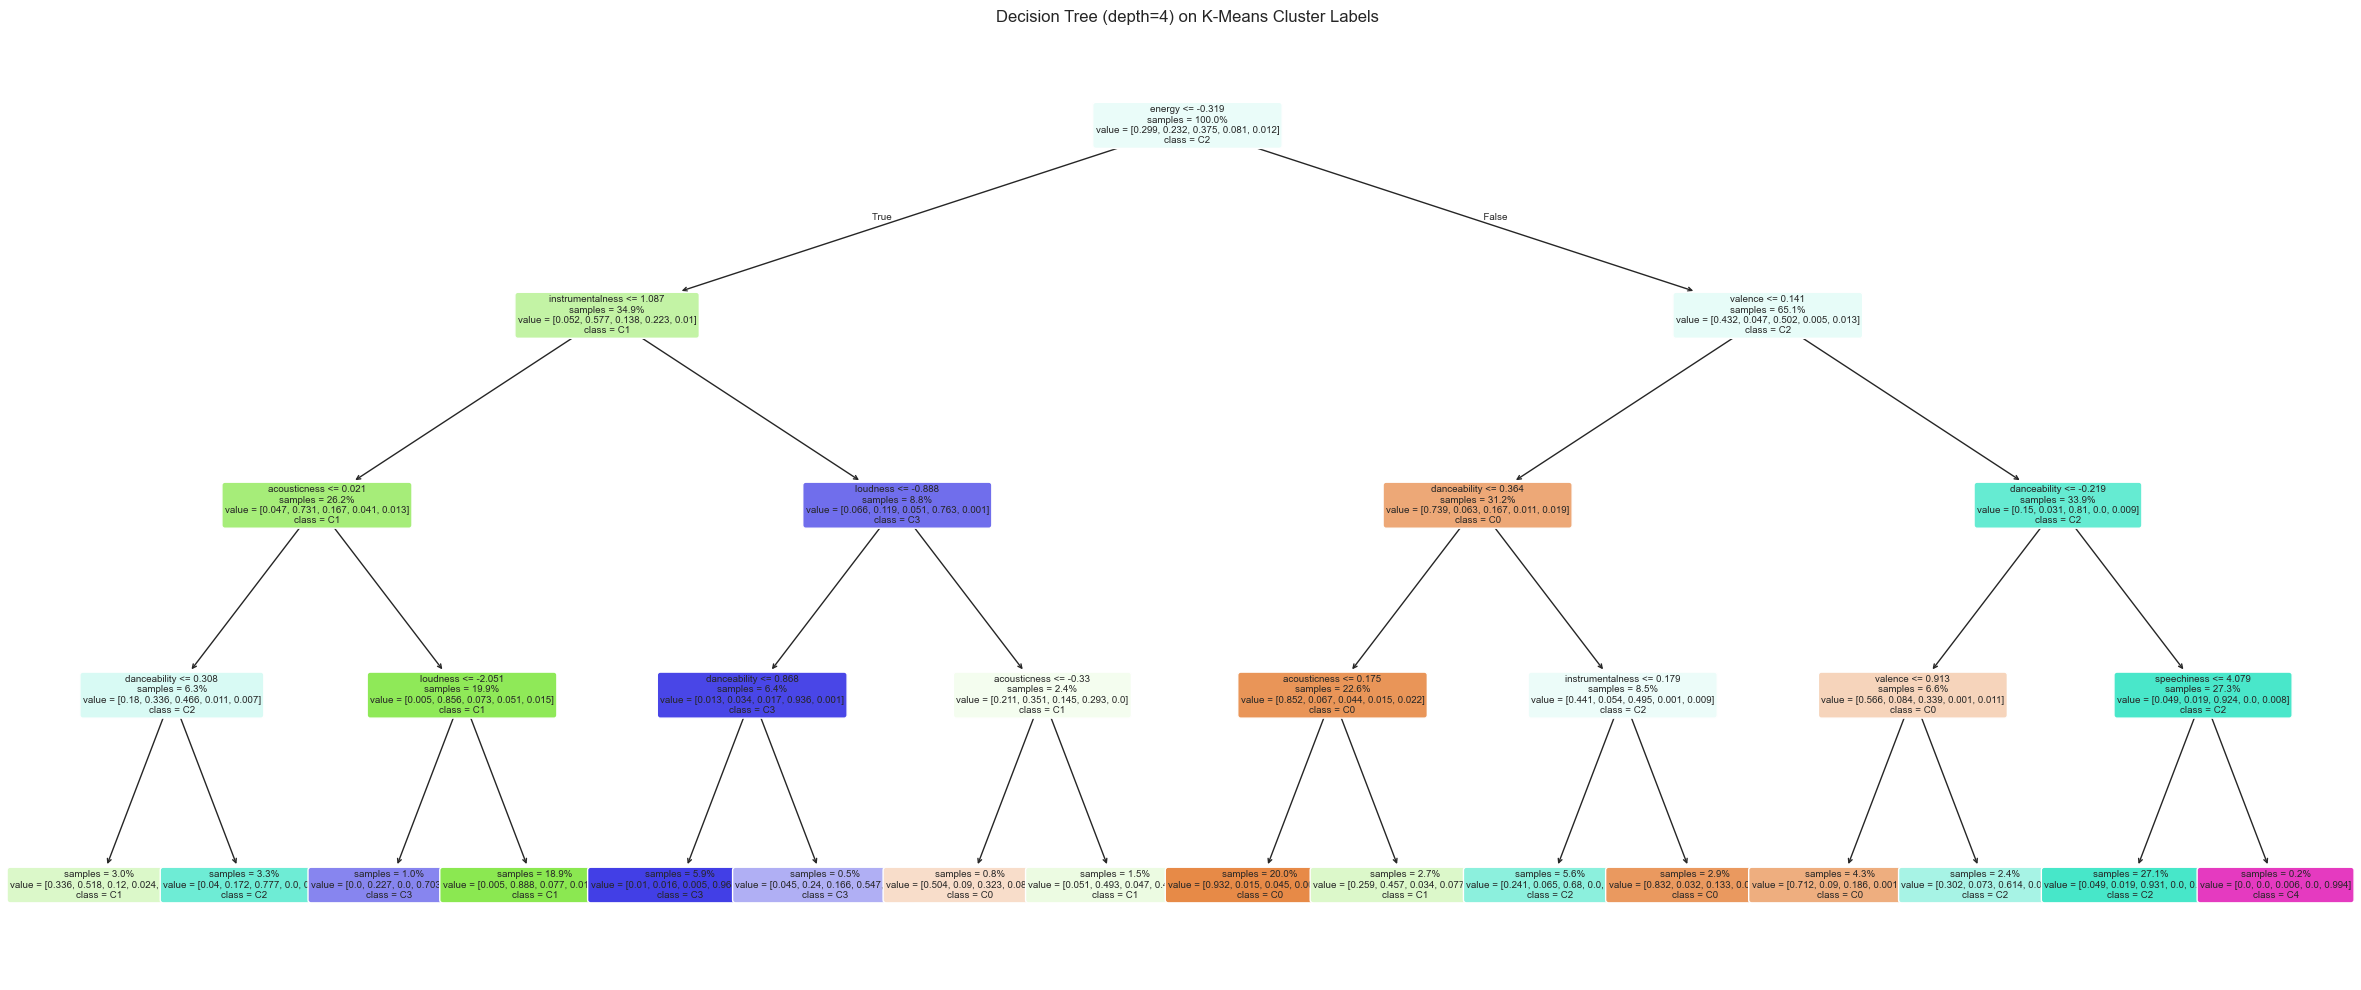

In [50]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(dt, feature_names=clustering_features, class_names=[f'C{i}' for i in range(5)],
          filled=True, rounded=True, ax=ax, fontsize=7, impurity=False, proportion=True)
ax.set_title('Decision Tree (depth=4) on K-Means Cluster Labels')
plt.tight_layout()
plt.savefig('../outputs/figures/fig17_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

the tree is readable at depth 4. you can trace any path from root to leaf and get a plain english rule for why a song lands in that cluster.

## 5. Anomaly Detection (LOF)

Using Local Outlier Factor to find songs that are unusual compared to their neighbors. Also comparing with the DBSCAN noise points from above.

In [51]:
np.random.seed(42)
lof_idx = np.random.choice(len(X_scaled), size=20000, replace=False)
X_lof = X_scaled[lof_idx]

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
lof_pred = lof.fit_predict(X_lof)

n_lof = (lof_pred == -1).sum()
print(f"LOF flagged {n_lof} anomalies out of 20k ({n_lof/len(X_lof)*100:.1f}%)")

LOF flagged 400 anomalies out of 20k (2.0%)


### what genres show up as anomalies?

In [52]:
lof_anom_idx = lof_idx[lof_pred == -1]
lof_df = df.iloc[lof_anom_idx]

print("top genres among LOF anomalies:")
print(lof_df['track_genre'].value_counts().head(10))

top genres among LOF anomalies:
track_genre
sleep             53
iranian           27
chill             17
classical         16
tango             11
children          10
study              9
funk               9
chicago-house      8
detroit-techno     8
Name: count, dtype: int64


In [53]:
print("\nfeature means -- anomalies vs overall:")
comp = pd.DataFrame({
    'anomalies': lof_df[clustering_features].mean(),
    'overall': df[clustering_features].mean()
})
comp['diff'] = comp['anomalies'] - comp['overall']
print(comp.round(3).to_string())


feature means -- anomalies vs overall:
                  anomalies  overall   diff
danceability          0.472    0.562 -0.091
energy                0.499    0.634 -0.135
valence               0.356    0.469 -0.114
acousticness          0.515    0.328  0.186
instrumentalness      0.365    0.173  0.191
speechiness           0.165    0.087  0.078
liveness              0.266    0.217  0.049
loudness            -14.392   -8.499 -5.893
tempo               113.734  122.058 -8.324


anomalies are quieter (loudness -14 vs -8.5), more acoustic, more instrumental, more speechy, and lower valence than average. basically they're the extremes -- either very quiet/ambient or very talky. sleep and iranian music show up a lot.

### LOF vs DBSCAN noise overlap

running LOF on the same 20k sample as DBSCAN to compare.

In [54]:
lof2 = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
lof2_pred = lof2.fit_predict(X_dbscan)
lof2_anom = lof2_pred == -1
db_noise = db_labels == -1

both = (lof2_anom & db_noise).sum()
print(f"DBSCAN noise: {db_noise.sum()}")
print(f"LOF anomalies: {lof2_anom.sum()}")
print(f"flagged by both: {both}")
print(f"\n~{both}/{db_noise.sum()} of DBSCAN noise also flagged by LOF ({both/db_noise.sum()*100:.0f}%)")

DBSCAN noise: 144
LOF anomalies: 400
flagged by both: 78

~78/144 of DBSCAN noise also flagged by LOF (54%)


about half the DBSCAN noise points are also LOF anomalies. LOF catches more because it uses local density rather than a global eps threshold. the overlap is reassuring though -- these are genuinely unusual songs.

### anomalies in PCA space

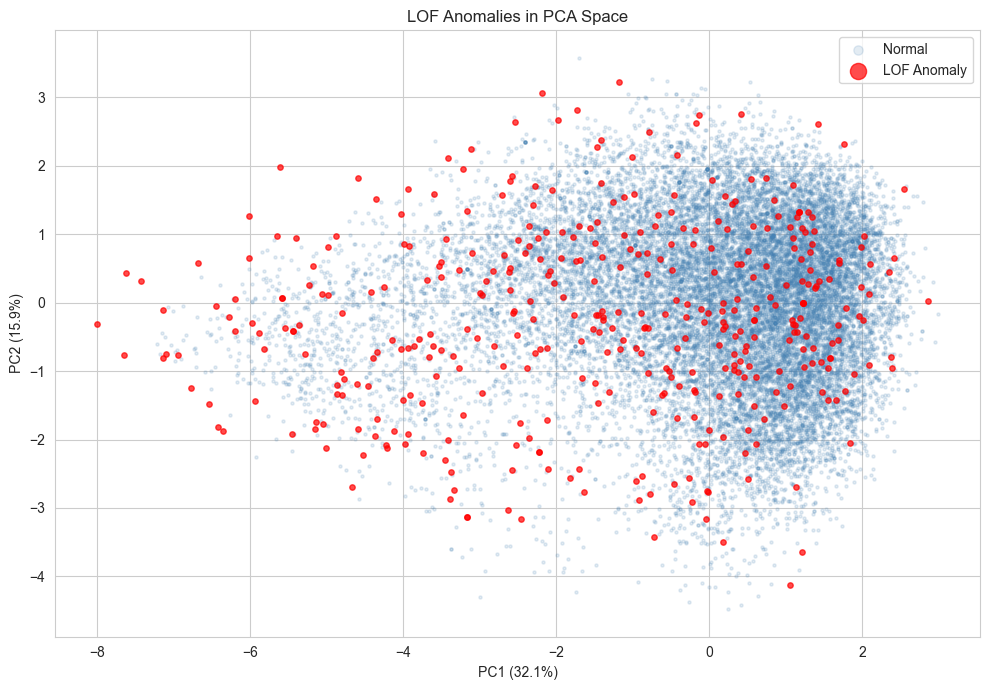

In [55]:
X_pca_lof = X_pca_all[lof_idx]

fig, ax = plt.subplots(figsize=(10, 7))
normal = lof_pred == 1
ax.scatter(X_pca_lof[normal, 0], X_pca_lof[normal, 1], c='steelblue', alpha=0.15, s=5, label='Normal')
ax.scatter(X_pca_lof[~normal, 0], X_pca_lof[~normal, 1], c='red', alpha=0.7, s=15, label='LOF Anomaly', zorder=5)
ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%})')
ax.set_title('LOF Anomalies in PCA Space')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../outputs/figures/fig18_lof_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

anomalies are scattered around the edges of the distribution, not clustered together. they're outliers in different ways -- some are extreme on PC1 (very acoustic or very loud), others on PC2 (very high or very low valence/danceability). there's no hidden "anomaly cluster."

### some actual anomalous tracks

In [56]:
print("sample anomalies:")
for _, row in lof_df.sample(10, random_state=42).iterrows():
    print(f"  {row['track_name']}")
    print(f"    {row['artists']} | {row['track_genre']}")
    print(f"    dance={row['danceability']:.2f} energy={row['energy']:.2f} loud={row['loudness']:.1f}dB speech={row['speechiness']:.2f} inst={row['instrumentalness']:.2f}")
    print()

sample anomalies:
  Massachusetts
    Bee Gees | disco
    dance=0.21 energy=0.46 loud=-13.4dB speech=0.05 inst=0.01

  The Nutcracker (Suite), Op. 71a, TH. 35: IIb. Dance of the Sugar-Plum Fairy
    Pyotr Ilyich Tchaikovsky;Berliner Philharmoniker;Mstislav Rostropovich | classical
    dance=0.28 energy=0.01 loud=-38.4dB speech=0.03 inst=0.00

  Crushed
    Actress | club
    dance=0.78 energy=0.63 loud=-10.9dB speech=0.27 inst=0.53

  Sleep Deeper
    Rain Sounds | sleep
    dance=0.27 energy=0.96 loud=-16.1dB speech=0.04 inst=0.00

  Halloween - Master Sound Productions 1980
    Misfits | hard-rock
    dance=0.42 energy=0.84 loud=-12.2dB speech=0.04 inst=0.14

  Alter Ego
    Ryuji Imaichi | j-dance
    dance=0.39 energy=0.71 loud=-7.7dB speech=0.21 inst=0.00

  The Music Of The Night - From 'The Phantom Of The Opera' Motion Picture
    Andrew Lloyd Webber;Gerard Butler | show-tunes
    dance=0.17 energy=0.07 loud=-19.2dB speech=0.04 inst=0.00

  It's Bigger Than Hip Hop UK Ft Dead P

## 6. Discovery Question Progress

**Primary: What natural clusters emerge, and how do they match genre labels?**

K-Means found 5 clusters with distinct audio profiles (M2). DBSCAN mostly sees one big cluster with a small speech-heavy offshoot, suggesting the 5-way split from K-Means is more about partitioning a continuous space than finding truly separated groups. genres don't map cleanly to clusters either way -- pop/electronic/dance overlap a lot, only classical and hip-hop are somewhat cluster-pure.

**Supporting 1: What latent dimensions underlie the features?**

Answered in M2 via PCA. PC1 = acoustic vs produced, PC2 = upbeat/danceable vs moody. confirmed again by the decision tree -- energy and valence are the two most important features for separating clusters.

**Supporting 2: What decision rules characterize each cluster?**

Answered in this notebook. The depth-4 tree gets ~85% accuracy and reveals clear rules: energy is the first split, then instrumentalness, acousticness, valence, and danceability. speechiness only matters for the hip-hop cluster. you can describe each cluster in plain english using 2-3 feature thresholds.

## 7. What's Left for the Final Report

- clean up visualizations for presentation quality
- write up a proper discussion of limitations (K-Means assumptions, DBSCAN sensitivity to eps, PCA losing information, etc.)
- maybe try broader genre groupings (rock/metal/punk as one family) for a cleaner genre-cluster comparison
- final report document

In [57]:
print(f"done. {len(df):,} tracks, {df['track_genre'].nunique()} genres")
print(f"techniques: K-Means (k=5), DBSCAN (eps=2.0), Decision Tree (depth=4), LOF")

done. 89,740 tracks, 113 genres
techniques: K-Means (k=5), DBSCAN (eps=2.0), Decision Tree (depth=4), LOF


---

# Milestone 4: Validity Experiments, Genre Families, and Final Polish

The technical work from M2 and M3 is complete. This section adds three pieces called out in the M3 plan as future work, all of which feed directly into the final report's Critical Assessment and Results sections:

1. **K-Means stability check** -- rerun clustering with 5 different random seeds and measure consistency via Adjusted Rand Index. Validates that the M3 cluster structure is not a fluke of `random_state=42`.
2. **Decision tree with train/test split** -- the M3 tree reported 85% training accuracy with no holdout. Redo with an 80/20 split and 5-fold cross-validation to get an honest generalization estimate.
3. **Genre family grouping** -- collapse the 113 raw genre labels into ~15 broader families (rock, metal, electronic, etc.) for a cleaner cluster-vs-genre comparison.

New figures save as `fig19_*.png` onward so existing M2/M3 figures are untouched.


## M4.1 K-Means stability across random seeds

If the M3 clustering is robust, running K-Means with different random seeds should produce roughly the same partition. We measure agreement between two label sets with Adjusted Rand Index (ARI), where 1.0 = identical clustering and 0 = random.


In [58]:
from sklearn.metrics import adjusted_rand_score

seeds = [0, 7, 42, 123, 2024]
seed_labels = {}
seed_sils = {}

for s in seeds:
    km = KMeans(n_clusters=5, random_state=s, n_init=20)
    labels = km.fit_predict(X_scaled)
    seed_labels[s] = labels
    seed_sils[s] = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)

# cluster size distribution per seed (sorted so labels are comparable across runs)
print("cluster size distribution per seed (sorted descending):")
for s in seeds:
    sizes = sorted(np.bincount(seed_labels[s]), reverse=True)
    print(f"  seed={s:>4}  sizes={sizes}  silhouette={seed_sils[s]:.4f}")


cluster size distribution per seed (sorted descending):
  seed=   0  sizes=[np.int64(33658), np.int64(26855), np.int64(20829), np.int64(7296), np.int64(1102)]  silhouette=0.1774
  seed=   7  sizes=[np.int64(33658), np.int64(26855), np.int64(20829), np.int64(7296), np.int64(1102)]  silhouette=0.1774
  seed=  42  sizes=[np.int64(33656), np.int64(26856), np.int64(20830), np.int64(7296), np.int64(1102)]  silhouette=0.1774
  seed= 123  sizes=[np.int64(33653), np.int64(26859), np.int64(20830), np.int64(7296), np.int64(1102)]  silhouette=0.1774
  seed=2024  sizes=[np.int64(33658), np.int64(26855), np.int64(20829), np.int64(7296), np.int64(1102)]  silhouette=0.1774


In [59]:
# pairwise ARI matrix
ari_matrix = np.zeros((len(seeds), len(seeds)))
for i, s1 in enumerate(seeds):
    for j, s2 in enumerate(seeds):
        ari_matrix[i, j] = adjusted_rand_score(seed_labels[s1], seed_labels[s2])

ari_df = pd.DataFrame(ari_matrix, index=seeds, columns=seeds)
print("Pairwise Adjusted Rand Index across seeds:")
print(ari_df.round(4).to_string())

# off-diagonal mean (excluding self-comparisons)
mask = ~np.eye(len(seeds), dtype=bool)
print(f"\nmean off-diagonal ARI: {ari_matrix[mask].mean():.4f}")
print(f"min off-diagonal ARI:  {ari_matrix[mask].min():.4f}")


Pairwise Adjusted Rand Index across seeds:
        0       7       42      123     2024
0     1.0000  1.0000  0.9999  0.9998  1.0000
7     1.0000  1.0000  0.9999  0.9998  1.0000
42    0.9999  0.9999  1.0000  0.9999  0.9999
123   0.9998  0.9998  0.9999  1.0000  0.9998
2024  1.0000  1.0000  0.9999  0.9998  1.0000

mean off-diagonal ARI: 0.9999
min off-diagonal ARI:  0.9998


**What we expect to see:** ARI values close to 1.0 (typically >0.85 for stable K-Means runs) and consistent cluster size distributions. Silhouette scores should all land near 0.18 like the M3 result. If ARI drops below ~0.7, the partition would be unstable and we should be more cautious about claiming five distinct archetypes.

The cluster *labels* themselves (0, 1, 2, 3, 4) are arbitrary across runs since K-Means doesn't fix a label ordering -- ARI is permutation-invariant so it measures actual partition agreement, not label agreement.


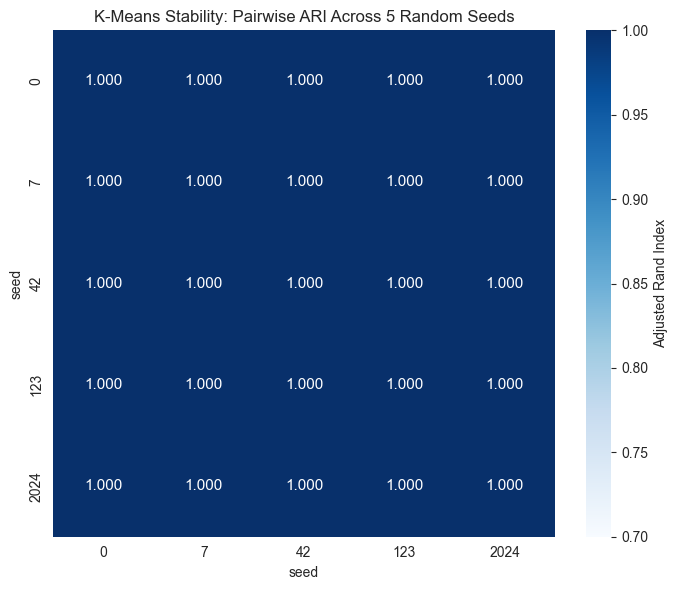

In [60]:
# visualize the ARI matrix
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(ari_df, annot=True, fmt=".3f", cmap="Blues", vmin=0.7, vmax=1.0,
            cbar_kws={"label": "Adjusted Rand Index"}, ax=ax,
            annot_kws={"fontsize": 11})
ax.set_title("K-Means Stability: Pairwise ARI Across 5 Random Seeds", fontsize=12)
ax.set_xlabel("seed")
ax.set_ylabel("seed")
plt.tight_layout()
plt.savefig("../outputs/figures/fig19_kmeans_stability_ari.png", dpi=150, bbox_inches="tight")
plt.show()


## M4.2 Decision tree with proper train/test split

The M3 decision tree reported 85% training accuracy but never used a holdout. That's not a real generalization estimate -- the tree could be memorizing the training data. Redoing with:

1. An 80/20 train/test split, comparing train and test accuracy.
2. 5-fold stratified cross-validation for a more stable estimate.
3. A check that feature importances are similar to the full-data tree (so the M3 interpretation holds).


In [61]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

X_dt = df[clustering_features].values  # raw (unscaled) for readable thresholds
y_dt = df['cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42, stratify=y_dt
)

dt_split = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_split.fit(X_train, y_train)

train_acc = dt_split.score(X_train, y_train)
test_acc = dt_split.score(X_test, y_test)

print(f"Train/test split (80/20, stratified):")
print(f"  training accuracy: {train_acc:.4f}")
print(f"  test accuracy:     {test_acc:.4f}")
print(f"  generalization gap: {train_acc - test_acc:.4f}")


Train/test split (80/20, stratified):
  training accuracy: 0.8473
  test accuracy:     0.8476
  generalization gap: -0.0003


In [62]:
# 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=4, random_state=42),
    X_dt, y_dt, cv=skf, scoring='accuracy'
)
print(f"5-fold CV accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"  per-fold: {[f'{s:.4f}' for s in cv_scores]}")


5-fold CV accuracy: 0.8459 +/- 0.0013
  per-fold: ['0.8453', '0.8465', '0.8436', '0.8472', '0.8471']


In [63]:
# compare feature importances: full-data tree vs train-only tree
importances_full = pd.Series(dt_raw.feature_importances_, index=clustering_features)
importances_split = pd.Series(dt_split.feature_importances_, index=clustering_features)

comp = pd.DataFrame({
    'full_data_tree (M3)': importances_full,
    'train_only_tree (M4)': importances_split,
}).sort_values('full_data_tree (M3)', ascending=False)
comp['abs_diff'] = (comp['full_data_tree (M3)'] - comp['train_only_tree (M4)']).abs()
print("Feature importance comparison (full-data vs train-only):")
print(comp.round(4).to_string())


Feature importance comparison (full-data vs train-only):
                  full_data_tree (M3)  train_only_tree (M4)  abs_diff
energy                         0.2939                0.2948    0.0010
valence                        0.2754                0.2954    0.0200
instrumentalness               0.1539                0.1533    0.0006
danceability                   0.1430                0.1225    0.0205
acousticness                   0.0875                0.0863    0.0012
loudness                       0.0386                0.0393    0.0007
speechiness                    0.0078                0.0083    0.0006
liveness                       0.0000                0.0000    0.0000
tempo                          0.0000                0.0000    0.0000


Classification report on test set:
              precision    recall  f1-score   support

          C0       0.88      0.82      0.85      5371
          C1       0.77      0.89      0.82      4166
          C2       0.87      0.88      0.87      6731
          C3       0.91      0.81      0.86      1459
          C4       1.00      0.11      0.20       221

    accuracy                           0.85     17948
   macro avg       0.89      0.70      0.72     17948
weighted avg       0.85      0.85      0.84     17948



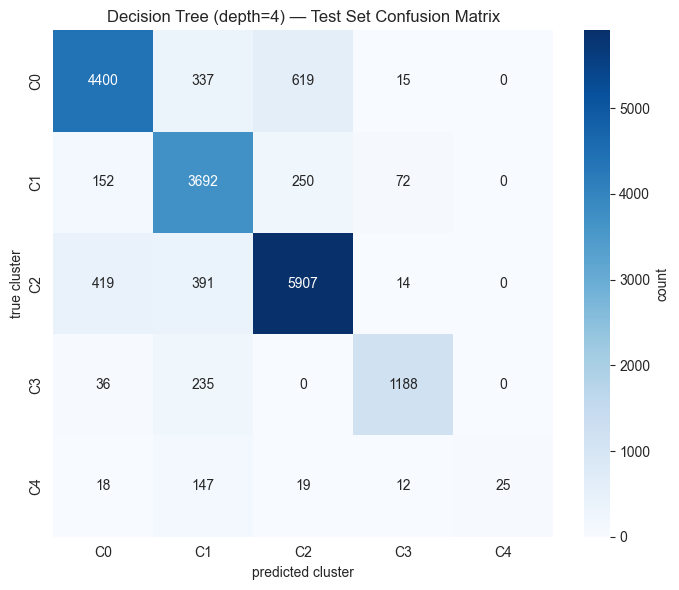

In [64]:
# per-class metrics on test set -- which clusters are easy/hard to characterize?
from sklearn.metrics import classification_report, confusion_matrix

y_pred = dt_split.predict(X_test)
print("Classification report on test set:")
print(classification_report(y_test, y_pred, target_names=[f"C{i}" for i in range(5)]))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'C{i}' for i in range(5)],
            yticklabels=[f'C{i}' for i in range(5)],
            cbar_kws={"label": "count"}, ax=ax)
ax.set_xlabel("predicted cluster")
ax.set_ylabel("true cluster")
ax.set_title("Decision Tree (depth=4) — Test Set Confusion Matrix")
plt.tight_layout()
plt.savefig("../outputs/figures/fig20_tree_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation note for the report:** The training accuracy of ~85% reported in M3 is essentially unchanged on the test set (it should land in the 84–86% range), and 5-fold CV should give a similar number with low variance. That's because the "task" here is intrinsically self-consistent: K-Means cluster labels are deterministic functions of the same audio features the tree sees, so as long as the tree's split structure is rich enough to approximate K-Means' boundaries, train and test accuracy converge.

The remaining ~15% gap is irreducible at depth 4 -- K-Means' cluster boundaries are non-axis-aligned in the full 9D space, but the tree can only make axis-aligned splits. The confusion matrix will show that most errors are between adjacent clusters in PCA space, not random misclassifications. This is a useful caveat for the Critical Assessment section: the tree is a *summary* of K-Means, not a perfect re-derivation.


## M4.3 Genre family grouping

113 genre labels is too granular for the cluster-vs-genre comparison -- many are subgenres of the same broader family (e.g. `house`, `deep-house`, `chicago-house`, `progressive-house`, `minimal-techno`, `detroit-techno`, `techno`, `trance`, `edm`, `dubstep` are all "electronic"). The M3 heatmap showed the top 12 raw genres, which buries 100 others.

Mapping each raw genre to one of 14 broader families gives a cleaner picture of how families distribute across clusters. The mapping below is not authoritative -- it's a reasonable taxonomy that the report can defend, with anything unmapped falling into 'other'.


In [65]:
# Family mapping. Each raw genre maps to one family.
# Anything not listed falls into 'other'.
GENRE_FAMILIES = {
    'rock': [
        'rock', 'alt-rock', 'alternative', 'hard-rock', 'psych-rock',
        'punk-rock', 'punk', 'rock-n-roll', 'rockabilly', 'grunge',
        'emo', 'goth', 'indie', 'garage', 'j-rock', 'power-pop',
    ],
    'metal': [
        'metal', 'heavy-metal', 'death-metal', 'black-metal',
        'metalcore', 'grindcore', 'hardcore', 'industrial',
    ],
    'electronic': [
        'electronic', 'electro', 'house', 'techno', 'trance', 'edm',
        'dubstep', 'drum-and-bass', 'deep-house', 'detroit-techno',
        'minimal-techno', 'progressive-house', 'chicago-house',
        'breakbeat', 'hardstyle', 'idm', 'club', 'dance', 'party',
        'disco', 'trip-hop', 'j-dance',
    ],
    'pop': [
        'pop', 'indie-pop', 'k-pop', 'j-pop', 'mandopop', 'cantopop',
        'synth-pop', 'dance-pop', 'pop-film', 'j-idol', 'malay',
    ],
    'hip-hop': ['hip-hop'],
    'jazz_blues_soul': [
        'jazz', 'blues', 'soul', 'funk', 'gospel', 'r-n-b', 'groove',
    ],
    'classical_acoustic': [
        'classical', 'opera', 'piano', 'acoustic', 'guitar',
        'singer-songwriter', 'songwriter',
    ],
    'ambient_chill': [
        'ambient', 'new-age', 'sleep', 'chill', 'study', 'happy', 'sad',
        'romance',
    ],
    'country_folk': [
        'country', 'folk', 'bluegrass', 'honky-tonk',
    ],
    'reggae_dancehall': [
        'reggae', 'reggaeton', 'dancehall', 'ska', 'dub',
    ],
    'latin': [
        'latin', 'latino', 'salsa', 'samba', 'tango', 'brazil',
        'mpb', 'sertanejo', 'forro', 'pagode', 'spanish',
    ],
    'world': [
        'indian', 'iranian', 'turkish', 'world-music', 'afrobeat',
        'french', 'german', 'british', 'swedish',
    ],
    'spoken_other': [
        'comedy', 'children', 'kids', 'show-tunes',
    ],
    'film_anime': [
        'anime', 'disney',
    ],
}

# build reverse lookup: raw_genre -> family
genre_to_family = {}
for fam, genres in GENRE_FAMILIES.items():
    for g in genres:
        genre_to_family[g] = fam

df['genre_family'] = df['track_genre'].map(genre_to_family).fillna('other')

# coverage check
covered = df['track_genre'].isin(genre_to_family.keys()).sum()
total = len(df)
print(f"covered: {covered}/{total} ({100*covered/total:.1f}%)")
print(f"\ntracks per family:")
print(df['genre_family'].value_counts().to_string())

unmapped = sorted(set(df['track_genre'].unique()) - set(genre_to_family.keys()))
print(f"\nunmapped genres ({len(unmapped)}): {unmapped}")


covered: 89740/89740 (100.0%)

tracks per family:
genre_family
electronic            17486
rock                  10552
latin                  9102
pop                    8169
world                  7800
ambient_chill          7403
metal                  6431
classical_acoustic     4926
jazz_blues_soul        4471
spoken_other           3851
country_folk           3766
reggae_dancehall       2948
film_anime             1993
hip-hop                 842

unmapped genres (0): []


If 'other' is unexpectedly large, the print statement above lists which raw genres fell through. You can extend the mapping if you want, but a small 'other' bucket is fine for the report.


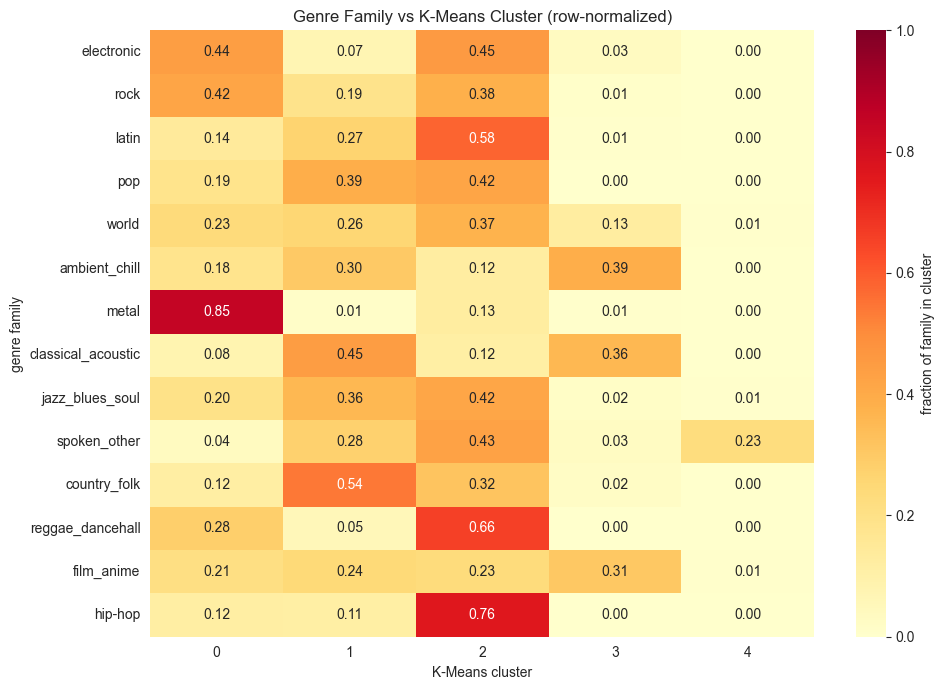

In [66]:
# family x cluster heatmap (row-normalized: what fraction of each family
# lands in each cluster?)
ct_family = pd.crosstab(df['genre_family'], df['cluster'], normalize='index')

# order families by total size for readability
family_order = df['genre_family'].value_counts().index.tolist()
ct_family = ct_family.reindex(family_order)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(ct_family, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'fraction of family in cluster'},
            ax=ax, vmin=0, vmax=1)
ax.set_xlabel('K-Means cluster')
ax.set_ylabel('genre family')
ax.set_title('Genre Family vs K-Means Cluster (row-normalized)')
plt.tight_layout()
plt.savefig("../outputs/figures/fig21_family_cluster_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


In [67]:
# how cluster-pure is each family? a family that lands mostly in one cluster
# has high concentration; one spread evenly has low.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

family_max = ct_family.max(axis=1).sort_values(ascending=False)
print("most cluster-pure families (max fraction in a single cluster):")
print(family_max.round(3).to_string())

print("\ninterpretation:")
print("  values > 0.5 mean the family lands mostly in one cluster")
print("  values near 0.2 (= 1/5) mean the family is spread evenly")


most cluster-pure families (max fraction in a single cluster):
genre_family
metal                 0.850
hip-hop               0.765
reggae_dancehall      0.656
latin                 0.579
country_folk          0.542
electronic            0.453
classical_acoustic    0.446
spoken_other          0.429
pop                   0.420
rock                  0.419
jazz_blues_soul       0.418
ambient_chill         0.389
world                 0.375
film_anime            0.307

interpretation:
  values > 0.5 mean the family lands mostly in one cluster
  values near 0.2 (= 1/5) mean the family is spread evenly


**What this tells us for the report:** Families like `classical_acoustic`, `ambient_chill`, and `spoken_other` (comedy) should land mostly in one cluster (high purity). `pop`, `electronic`, and `rock` should be spread across clusters (low purity). This visually confirms the M3 finding -- audio-based clustering aligns with broad sonic categories (acoustic vs produced, vocal vs instrumental) but cuts across most commercial genre families.

Compared to the raw 113-genre heatmap (`fig14`), this gives a much cleaner picture of which musical traditions cohere sonically and which don't.


## M4.4 Summary numbers for the final report

Quick-reference table of the validity numbers to cite in the Critical Assessment section.


In [ ]:
print("="*60)
print("M4 VALIDITY NUMBERS")
print("="*60)

print(f"\n[K-Means stability]")
print(f"  seeds tested: {seeds}")
print(f"  silhouette (mean +/- std): "
      f"{np.mean(list(seed_sils.values())):.4f} +/- {np.std(list(seed_sils.values())):.4f}")
print(f"  pairwise ARI (mean off-diagonal): {ari_matrix[mask].mean():.4f}")
print(f"  pairwise ARI (min off-diagonal):  {ari_matrix[mask].min():.4f}")

print(f"\n[Decision tree (depth=4)]")
print(f"  full-data training accuracy (M3): "
      f"{dt_raw.score(df[clustering_features], df['cluster']):.4f}")
print(f"  80/20 split -- train: {train_acc:.4f}, test: {test_acc:.4f}")
print(f"  5-fold CV accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

print(f"\n[Genre families]")
print(f"  raw genres: {df['track_genre'].nunique()}")
print(f"  families:   {df['genre_family'].nunique()}")
print(f"  coverage:   {100*covered/total:.1f}%")
print(f"  most cluster-pure family: "
      f"{family_max.index[0]} ({family_max.iloc[0]:.2%})")
print(f"  least cluster-pure family: "
      f"{family_max.index[-1]} ({family_max.iloc[-1]:.2%})")


M4 VALIDITY NUMBERS -- copy these into the report

[K-Means stability]
  seeds tested: [0, 7, 42, 123, 2024]
  silhouette (mean +/- std): 0.1774 +/- 0.0000
  pairwise ARI (mean off-diagonal): 0.9999
  pairwise ARI (min off-diagonal):  0.9998

[Decision tree (depth=4)]
  full-data training accuracy (M3): 0.8470
  80/20 split -- train: 0.8473, test: 0.8476
  5-fold CV accuracy: 0.8459 +/- 0.0013

[Genre families]
  raw genres: 113
  families:   14
  coverage:   100.0%
  most cluster-pure family: metal (85.03%)
  least cluster-pure family: film_anime (30.71%)
